Ноутбук показывает:

1. Шесть геометрий в симметричном виде на одном полотне.
2. Аппроксимацию канала цилиндрами и конусами, включая трубу с дыркой.
3. Сравнение скорости работы solver-ов.
4. Сравнение относительной ошибки относительно выбранного reference solver и показ худшего случая в dB.

In [1]:
import math
import statistics
import matplotlib.pyplot as plt
import vt_all_solvers_wrapper as vt
from base_range_library import range_library

import sys
from pathlib import Path

STYLE_DIR = Path("style").resolve()
if str(STYLE_DIR) not in sys.path:
    sys.path.insert(0, str(STYLE_DIR))

import diploma_style as ds
ds.apply_style(font_size=12, fig_width_cm=18.0, fig_height_cm=10.0, dpi=140, closed_frame=True)
COLORS = dict(ds.COLORS)
COLORS["orange"] = "#FF7A00"
COLORS["cylinders"] = COLORS["orange"]
COLORS["cones"] = COLORS["green"]
plt.rcParams["axes.prop_cycle"] = plt.cycler(
    color=[
        COLORS["blue"],
        COLORS["orange"],
        COLORS["green"],
        COLORS["red"],
        COLORS["purple"],
        COLORS["cyan"],
        COLORS["pink"],
    ]
)

TEXT_REPLACEMENTS = [
    ("Mean runtime", "Среднее время работы"),
    ("Runtime histograms", "Распределение времени работы"),
    ("Relative error vs", "Относительная ошибка относительно"),
    ("Worst-case example vs", "Худший случай относительно"),
    ("Worst-Case Transfer Function Comparison", "Сравнение передаточных функций в худшем случае"),
    ("Worst Case: Cylindrical Approximation", "Худший случай: цилиндрическая аппроксимация"),
    ("Worst Case: Cone Approximation", "Худший случай: коническая аппроксимация"),
    ("Worst-case", "Худший случай"),
    ("Worst Case", "Худший случай"),
    ("Worst for cylinders", "Худший случай для цилиндров"),
    ("Worst for cones", "Худший случай для конусов"),
    ("Approximation quality on random geometries", "Качество аппроксимации на случайных геометриях"),
    ("Distribution of approximation errors", "Распределение ошибок аппроксимации"),
    ("Approximation error vs number of sections", "Ошибка аппроксимации в зависимости от числа секций"),
    ("Runtime vs frequency grid size", "Время работы в зависимости от числа частот"),
    ("Runtime vs profile discretization", "Время работы в зависимости от дискретизации профиля"),
    ("Neural surrogate speedup", "Ускорение нейросетевых моделей"),
    ("Numerical transfer functions", "Численные передаточные функции"),
    ("Same channel shape, different area scale", "Одинаковая форма канала при разном масштабе площади"),
    ("Same channel profile, full geometric scaling", "Одинаковый профиль канала при полном геометрическом масштабировании"),
    ("Tube Geometry and Cone Approximation", "Геометрия канала и коническая аппроксимация"),
    ("First 30 training channel profiles", "Первые 30 профилей каналов из обучающей выборки"),
    ("Numerical transfer functions for the same 30 channels", "Численные передаточные функции для тех же 30 каналов"),
    ("Mean relative area error", "Средняя относительная ошибка площади"),
    ("mean relative area error", "средняя относительная ошибка площади"),
    ("mean relative magnitude error", "средняя относительная ошибка амплитуды"),
    ("mean relative error", "средняя относительная ошибка"),
    ("mean time", "среднее время"),
    ("time per sample", "время на образец"),
    ("time", "время"),
    ("number of frequency points", "число частотных точек"),
    ("profile discretization points", "число точек дискретизации профиля"),
    ("number of sections", "число секций"),
    ("section_count", "число секций"),
    ("frequency", "частота"),
    ("Frequency", "Частота"),
    ("Transfer function", "Передаточная функция"),
    ("Difference", "Разность"),
    ("radius", "радиус"),
    ("solver", "солвер"),
    ("count", "количество"),
    ("speedup, cone / model", "ускорение, конусный солвер / модель"),
    ("cone solver", "конический солвер"),
    ("cylinders", "цилиндры"),
    ("cylinder", "цилиндр"),
    ("conical", "конический профиль"),
    ("cones", "конусы"),
    ("cone", "конус"),
    ("reference", "эталон"),
    ("original", "исходный профиль"),
    ("solution", "решение"),
    ("channel", "канал"),
    ("profile scale", "масштаб профиля"),
    ("scale", "масштаб"),
    ("random_piecewise", "случайный кусочно-постоянный профиль"),
    ("tube_with_hole", "труба с отверстием"),
    ("random_smooth", "случайный гладкий профиль"),
    ("three_point", "трехточечный профиль"),
    ("db", "дБ"),
    ("dB", "дБ"),
    ("Hz", "Гц"),
    ("ms", "мс"),
    (", s", ", с"),
    (", m", ", м"),
    ("%", "%"),
    (" -> ", " → "),
    ("mean err", "средняя ошибка"),
]

MODEL_LABELS_RU = {
    "MLP": "MLP",
    "FNO": "FNO",
    "DeepONet": "DeepONet",
    "FiLM DeepONet": "FiLM-DeepONet",
    "Bilinear DeepONet": "Bilinear DeepONet",
    "Attention DeepONet": "Attention DeepONet",
    "SIREN DeepONet": "SIREN-DeepONet",
    "Mamba Fusion DeepONet": "Mamba Fusion DeepONet",
    "Dynamic DeepONet": "Dynamic DeepONet",
    "Deformable DeepONet": "Deformable DeepONet",
}

def ru_text(text):
    text = str(text)
    text = MODEL_LABELS_RU.get(text, text)
    for old, new in TEXT_REPLACEMENTS:
        text = text.replace(old, new)
    return text

def russify_current_figure(fig=None):
    fig = plt.gcf() if fig is None else fig
    for ax in fig.axes:
        ax.set_title(ru_text(ax.get_title()))
        ax.set_xlabel(ru_text(ax.get_xlabel()))
        ax.set_ylabel(ru_text(ax.get_ylabel()))

        legend = ax.get_legend()
        if legend is not None:
            for item in legend.get_texts():
                item.set_text(ru_text(item.get_text()))

        xticks = ax.get_xticklabels()
        if xticks:
            for item in xticks:
                item.set_text(ru_text(item.get_text()))

        yticks = ax.get_yticklabels()
        if yticks:
            for item in yticks:
                item.set_text(ru_text(item.get_text()))

    for item in fig.texts:
        item.set_text(ru_text(item.get_text()))
    if getattr(fig, "_suptitle", None) is not None:
        fig._suptitle.set_text(ru_text(fig._suptitle.get_text()))
    return fig


FIGURE_OUTPUT_DIR = Path("article/images")
FIGURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
_SAVED_FIGURE_NAME_COUNTS = {}


def _figure_title(fig):
    if getattr(fig, "_suptitle", None) is not None:
        title = fig._suptitle.get_text().strip()
        if title:
            return title

    for ax in fig.axes:
        title = ax.get_title().strip()
        if title:
            return title

    for ax in fig.axes:
        ylabel = ax.get_ylabel().strip()
        xlabel = ax.get_xlabel().strip()
        if ylabel and xlabel:
            return f"{ylabel} от {xlabel}"
        if ylabel:
            return ylabel
        if xlabel:
            return xlabel

    return "график"


def _slugify_title(title):
    title = ru_text(title).lower()
    chars = []
    previous_was_separator = False

    for char in title:
        if char.isalnum():
            chars.append(char)
            previous_was_separator = False
        elif not previous_was_separator:
            chars.append("_")
            previous_was_separator = True

    slug = "".join(chars).strip("_")
    return slug or "график"


def remove_figure_titles(fig=None):
    fig = plt.gcf() if fig is None else fig

    if getattr(fig, "_suptitle", None) is not None:
        fig._suptitle.set_text("")

    for ax in fig.axes:
        ax.set_title("")

    return fig


def save_current_figure(
    fig=None,
    *,
    output_dir=FIGURE_OUTPUT_DIR,
    dpi=300,
    filename_title=None,
    hide_titles=False,
    overwrite=True,
    translate_text=True,
):
    fig = plt.gcf() if fig is None else fig
    if translate_text:
        fig = russify_current_figure(fig)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    title = ru_text(filename_title) if filename_title is not None else _figure_title(fig)
    stem = _slugify_title(title)

    if hide_titles:
        remove_figure_titles(fig)

    if overwrite:
        filename = f"{stem}.png"
    else:
        count = _SAVED_FIGURE_NAME_COUNTS.get(stem, 0) + 1
        _SAVED_FIGURE_NAME_COUNTS[stem] = count
        filename = f"{stem}.png" if count == 1 else f"{stem}_{count}.png"

    path = output_dir / filename
    fig.savefig(path, dpi=dpi, bbox_inches="tight", facecolor="white")
    print(f"Сохранён график: {path}")
    return path

# Пересобираем solver CLI, чтобы не использовать старый несовместимый exe.
vt.build_binary(rebuild=True)

WindowsPath('C:/Users/George.LAPTOP-TLP259VH/Desktop/webster/bin/windows/vt_all_solvers_cli.exe')

In [2]:
def magnitude_to_db(magnitude, eps=1e-12):
    return [20.0 * math.log10(max(abs(v), eps)) for v in magnitude]


def make_demo_geometries(seed=None, smooth_n_harmonics=3):
    return {
        "cylinder": vt.make_cylinder_geometry(length_m=1.0, area_m2=8.0e-4),
        "conical": vt.make_conical_geometry(length_m=1.0, area_in_m2=4.0e-4, area_out_m2=3.0e-3),
        "three_point": vt.make_three_point_geometry(
            length_m=1.0,
            area_left_m2=5.0e-4,
            area_middle_m2=2.2e-3,
            area_right_m2=9.0e-4,
        ),
        "tube_with_hole": vt.make_tube_with_hole_geometry(
            length_m=1.0,
            base_width_m=0.05,
            random=False,
            hole_center_m=0.55,
        ),
        "random_smooth": vt.make_random_smooth_geometry(
            length_m=1.0,
            dx_m=0.025,
            area0_m2=1.1e-3,
            amp=0.28,
            n_harmonics=smooth_n_harmonics,
            seed=seed,
        ),
        "random_piecewise": vt.make_random_piecewise_geometry(
            length_m=1.0,
            mean_width_m=0.055,
            section_count=5,
            width_spread=0.33,
            seed=seed,
        ),
    }


def make_random_suite_from_range_library(range_library, n_cases=16, seed0=1000):
    suite = {}
    for i in range(n_cases):
        geom = vt.make_geometry_from_range_library("random", range_library, seed=seed0 + i)
        suite[f"sample_{i + 1:02d}"] = geom
    return suite


def benchmark_speed_from_range_library(
    range_library,
    n_runs=12,
    geometry_kind="random",
    solvers=("cylinder", "cone", "arma", "webster"),
    base_config=None,
    acoustics=None,
):
    if base_config is None:
        base_config = vt.SolverConfig(
            sections=24,
            points=256,
            f_min_hz=100.0,
            f_max_hz=3000.0,
            grid="linear",
            beta_loss_np_per_m=0.02,
            spatial_nodes=41,
            signal_sample_rate_hz=16000.0,
            signal_duration_s=0.04,
        )
    if acoustics is None:
        acoustics = vt.AcousticConfig()

    vt.build_binary()
    times_by_solver = {solver: [] for solver in solvers}
    geometries = []

    for run_idx in range(n_runs):
        geom = vt.make_geometry_from_range_library(geometry_kind, range_library, seed=run_idx + 1)
        geometries.append(geom)

        for solver_name in solvers:
            config = vt.SolverConfig(
                solver=solver_name,
                sections=base_config.sections,
                points=base_config.points,
                f_min_hz=base_config.f_min_hz,
                f_max_hz=base_config.f_max_hz,
                grid=base_config.grid,
                beta_loss_np_per_m=base_config.beta_loss_np_per_m,
                signal_sample_rate_hz=base_config.signal_sample_rate_hz,
                signal_duration_s=base_config.signal_duration_s,
                signal_f0_hz=base_config.signal_f0_hz,
                signal_f1_hz=base_config.signal_f1_hz,
                signal_amplitude=base_config.signal_amplitude,
                spatial_nodes=base_config.spatial_nodes,
                cfl=base_config.cfl,
                observation_node=base_config.observation_node,
            )

            import time
            t0 = time.perf_counter()
            _ = vt.solve(geometry=geom, config=config, acoustics=acoustics, rebuild=False)
            t1 = time.perf_counter()
            times_by_solver[solver_name].append(t1 - t0)

    return times_by_solver, geometries


def summarize_relative_errors(benchmark_results, reference_solver="cone"):
    solvers = list(benchmark_results[0].comparison.results.keys())
    summary = {}
    for solver in solvers:
        vals = [item.relative_errors[solver].mean_rel_mag_err for item in benchmark_results]
        summary[solver] = statistics.mean(vals)
    non_reference = [solver for solver in solvers if solver != reference_solver]
    worst_solver = max(
        non_reference,
        key=lambda solver: max(item.relative_errors[solver].mean_rel_mag_err for item in benchmark_results),
    )
    worst_case = max(
        benchmark_results,
        key=lambda item: item.relative_errors[worst_solver].mean_rel_mag_err,
    )
    return summary, worst_solver, worst_case


In [4]:
import matplotlib.pyplot as plt
import vt_all_solvers_wrapper as vt

# Геометрия
geometry = vt.make_conical_geometry(
    length_m=1.0,
    area_in_m2=5.0e-4,
    area_out_m2=2.5e-3,
)

# Конфиг решателя
solver_config = vt.SolverConfig(
    solver="cone",
    sections=100,
    points=512,
    f_min_hz=50.0,
    f_max_hz=5000.0,
    grid="linear",
    beta_loss_np_per_m=0.0,
)

# Решение
result = vt.solve(
    geometry=geometry,
    config=solver_config,
)

# Изумрудный цвет
EMERALD = "#009B77"

# График передаточной функции в дБ
plt.figure(figsize=(8, 5))
plt.plot(
    result.frequencies_hz,
    result.magnitude_db,
    color=EMERALD,
    linewidth=2.2,
    label="решение",
)

plt.xlabel("частота, Гц")
plt.ylabel("|H(f)|, дБ")
plt.title("Передаточная функция")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

AttributeError: 'SpectrumResult' object has no attribute 'magnitude_db'

<Figure size 1120x700 with 0 Axes>

## 1. Шесть геометрий в симметричном виде

Сохранён график: article\images\демонстрационные_геометрии.png


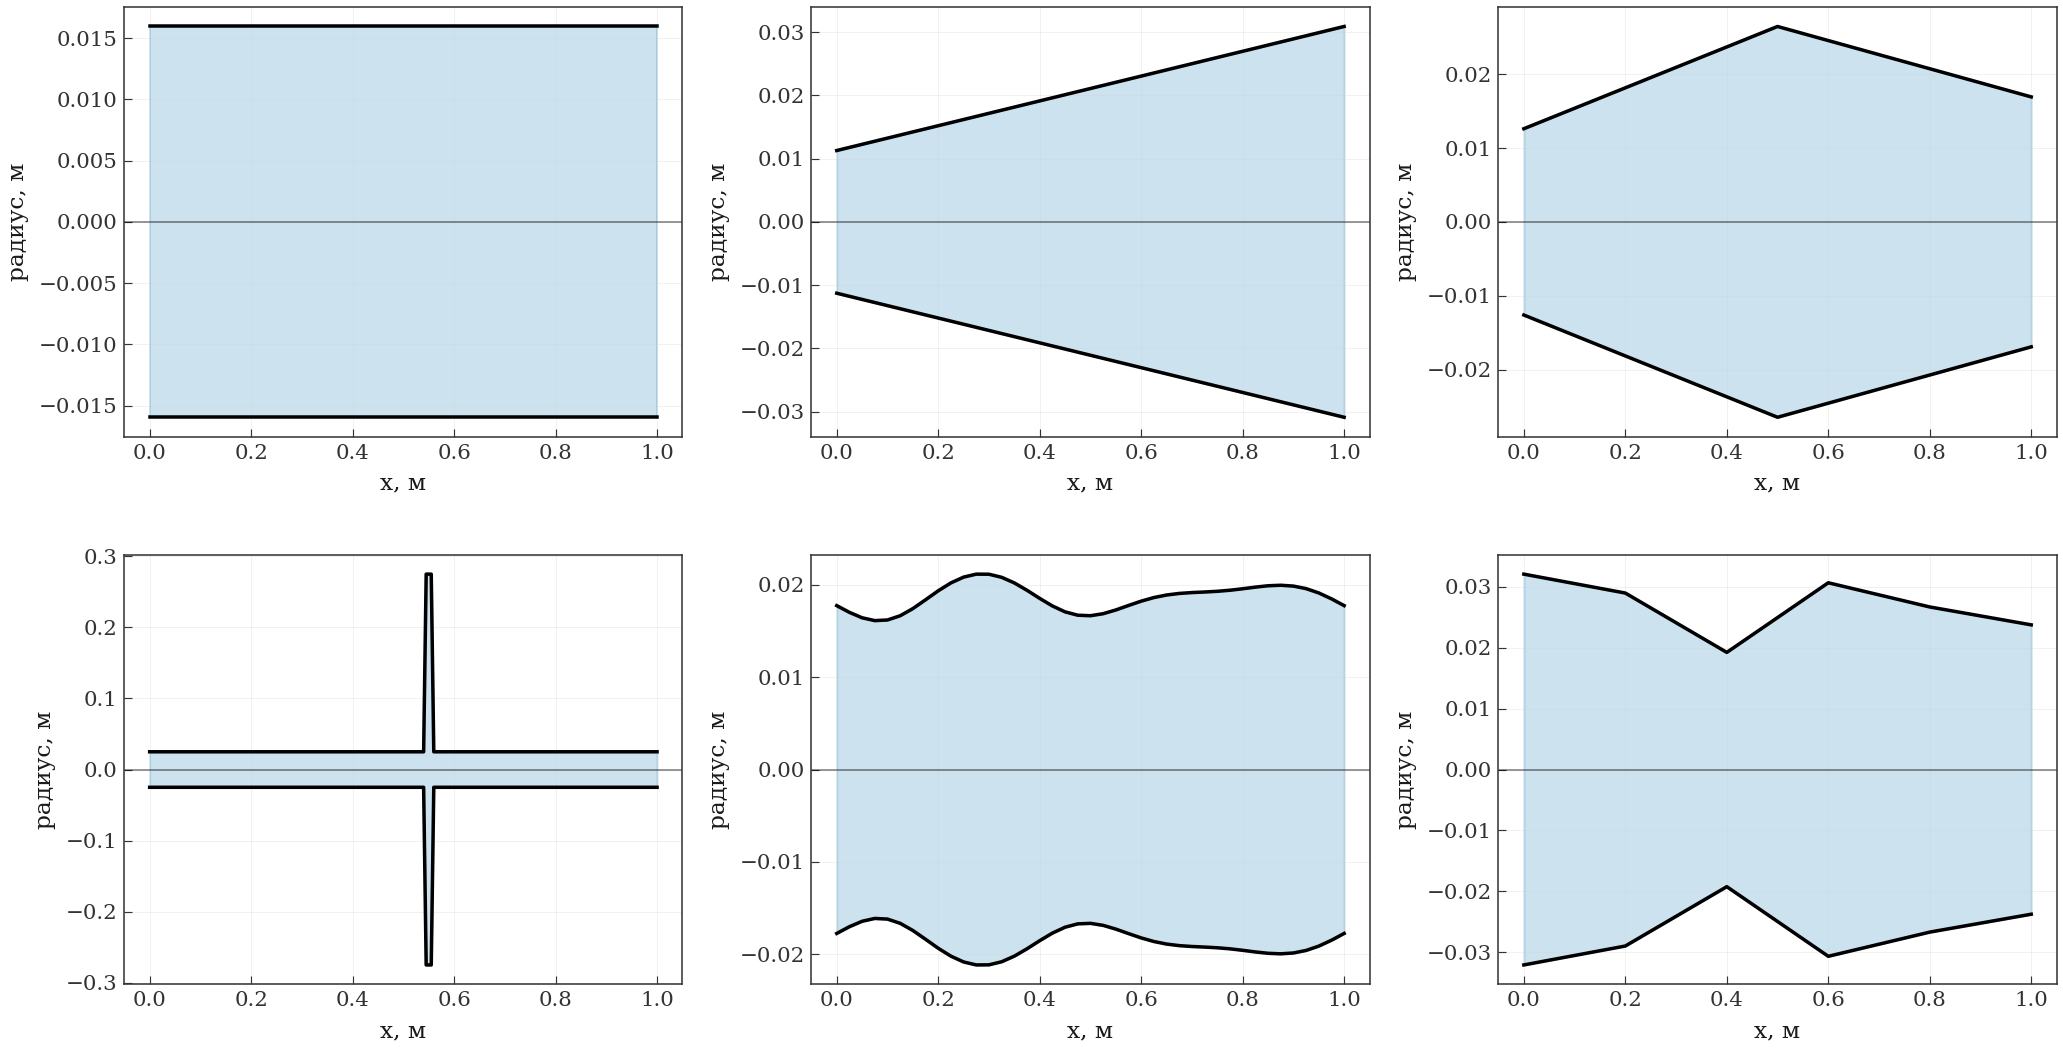

In [10]:
geometries = make_demo_geometries(seed=None, smooth_n_harmonics=3)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (name, geom) in zip(axes.ravel(), geometries.items()):
    vt.plot_geometry(
        geom,
        mode="symmetric",
        ax=ax,
        title=ru_text(name),
        equal_aspect=False,
        linewidth=1.8,
    )

plt.tight_layout()
save_current_figure(
    filename_title="Демонстрационные геометрии",
    hide_titles=True,
)
plt.show()
plt.close()

Сохранён график: article\images\демонстрационные_геометрии.png


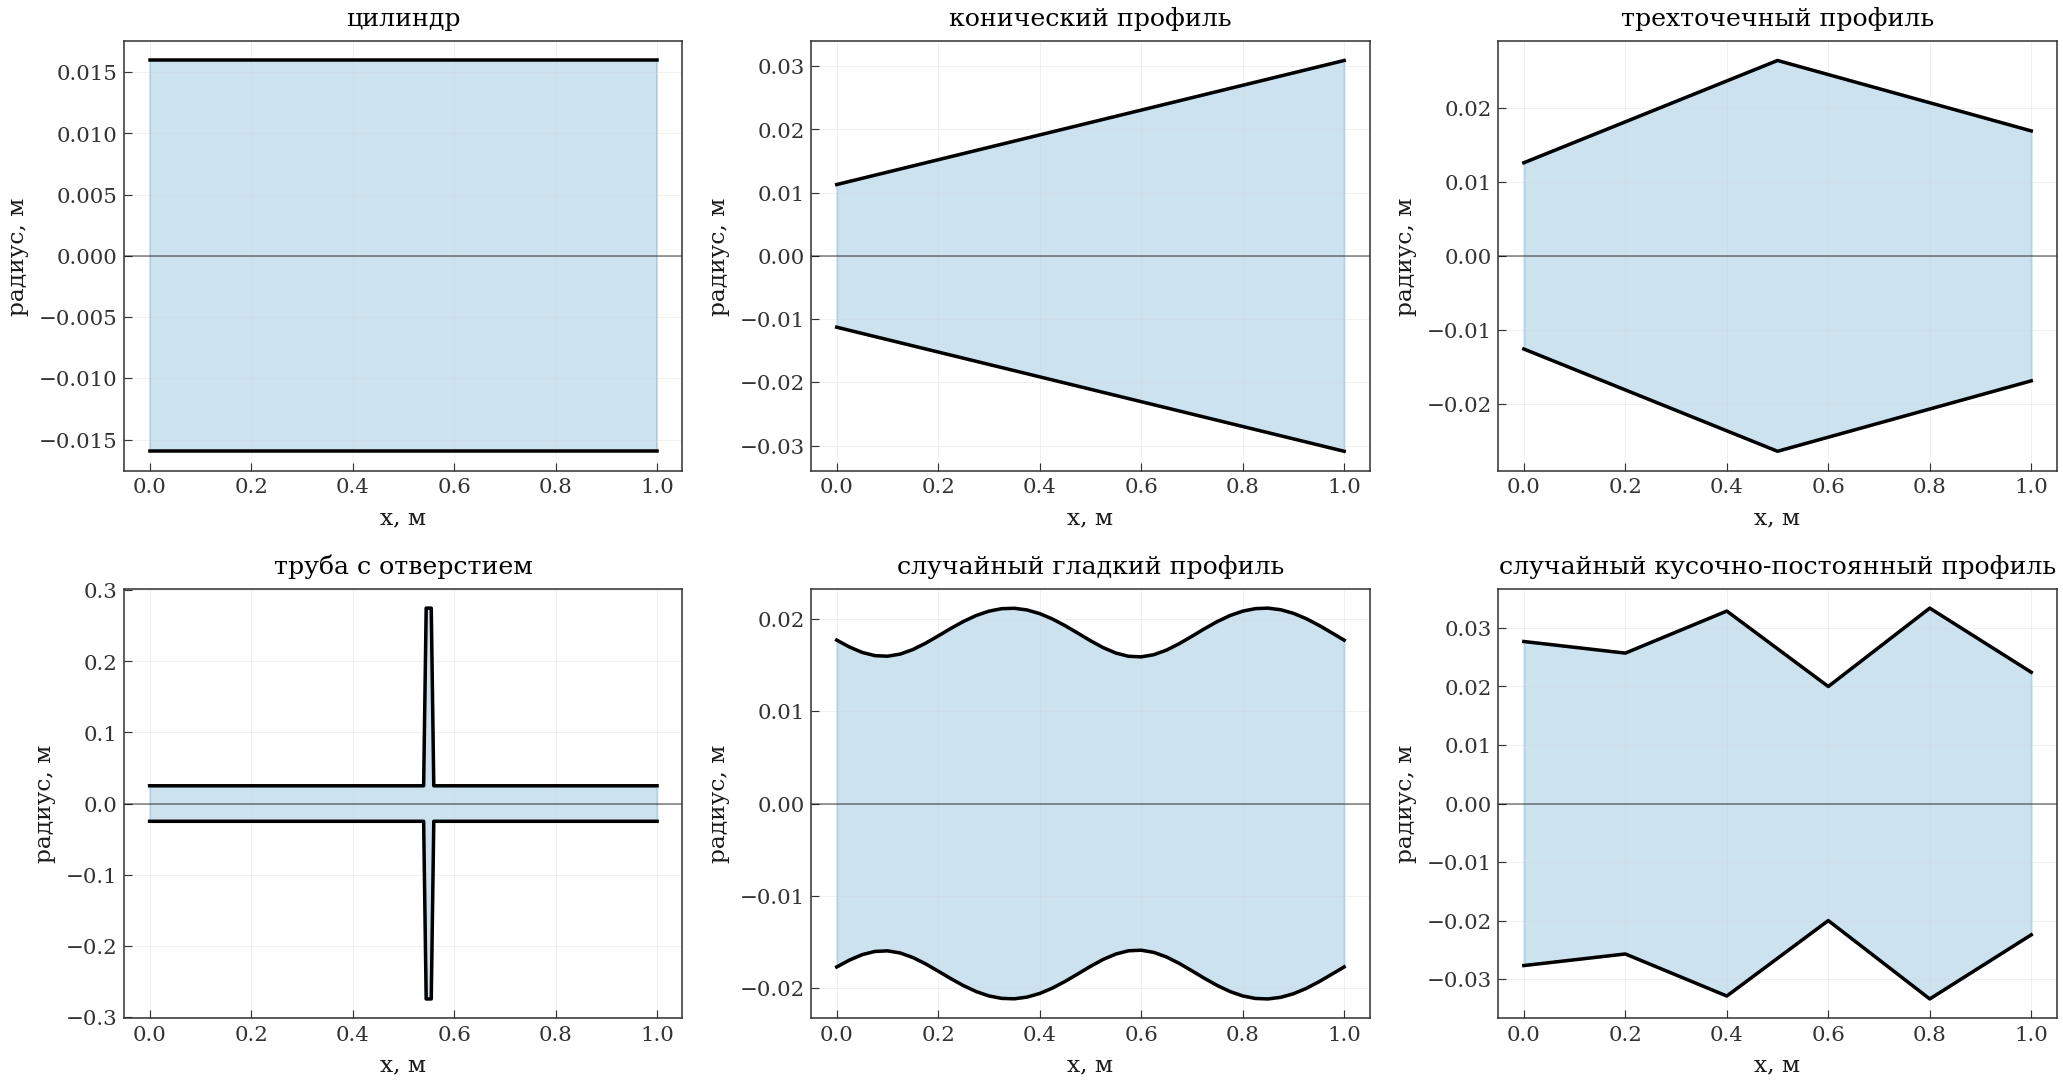

In [16]:
geometries = make_demo_geometries(seed=None, smooth_n_harmonics=2)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, (name, geom) in zip(axes.ravel(), geometries.items()):
    a = geom
    vt.plot_geometry(
        geom,
        mode="symmetric",
        ax=ax,
        title=ru_text(name),
        equal_aspect=False,
        linewidth=1.8,
    )

plt.tight_layout()
save_current_figure(
    filename_title="Демонстрационные геометрии",
    hide_titles=False,
)
plt.show()
plt.close()

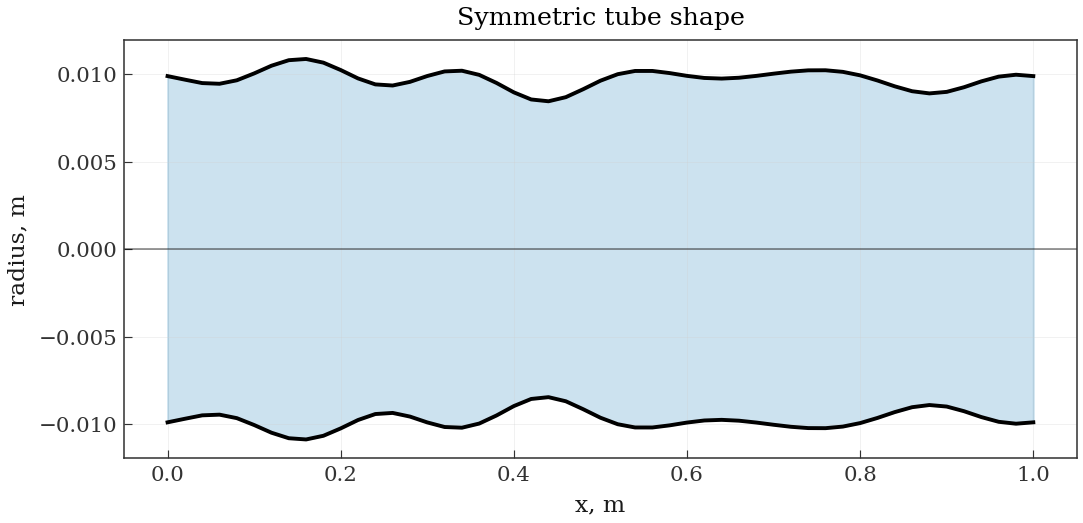

In [24]:
import matplotlib.pyplot as plt
import vt_all_solvers_wrapper as vt

geom = vt.make_random_smooth_geometry(
    length_m=1.0,
    dx_m=0.02,
    area0_m2=3.0e-4,
    amp=0.25,
    n_harmonics=6,
)

fig, ax = plt.subplots(figsize=(8, 4))
vt.plot_geometry(
    geom,
    mode="symmetric",
    ax=ax,
    title=None,
    equal_aspect=False,
    linewidth=2.0,
)
plt.tight_layout()
plt.show()

## 1b. Аппроксимация канала цилиндрами и конусами

Верхний ряд показывает обычный канал, нижний ряд показывает трубу с дыркой.

In [ ]:
geom_main = geometries["random_smooth"]
geom_hole = geometries["tube_with_hole"]
section_count = 7

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

vt.plot_geometry_approximation(
    geom_main,
    section_count=section_count,
    approx="cylinders",
    color_approx=COLORS["cylinders"],
    mode="symmetric",
    ax=axes[0, 0],
    title="случайный кусочно-постоянный профиль → цилиндры",
    equal_aspect=False,
)
vt.plot_geometry_approximation(
    geom_main,
    section_count=section_count,
    approx="cones",
    color_approx=COLORS["cones"],
    mode="symmetric",
    ax=axes[0, 1],
    title="случайный кусочно-постоянный профиль → конусы",
    equal_aspect=False,
)
vt.plot_geometry_approximation(
    geom_hole,
    section_count=section_count,
    approx="cylinders",
    color_approx=COLORS["cylinders"],
    mode="symmetric",
    ax=axes[1, 0],
    title="труба с отверстием → цилиндры",
    equal_aspect=False,
)
vt.plot_geometry_approximation(
    geom_hole,
    section_count=section_count,
    approx="cones",
    color_approx=COLORS["cones"],
    mode="symmetric",
    ax=axes[1, 1],
    title="труба с отверстием → конусы",
    equal_aspect=False,
)

plt.tight_layout()
save_current_figure(
    filename_title="Аппроксимация канала цилиндрами и конусами ",
    hide_titles=False,
)
plt.show()
plt.close()

In [ ]:
geom_main = geometries["random_smooth"]
geom_hole = geometries["tube_with_hole"]
section_count = 7

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

vt.plot_geometry_approximation(
    geom_main,
    section_count=section_count,
    approx="cylinders",
    color_approx=COLORS["cylinders"],
    mode="symmetric",
    ax=axes[0, 0],
    title="гладкий профиль → цилиндры",
    equal_aspect=False,
)
vt.plot_geometry_approximation(
    geom_main,
    section_count=section_count,
    approx="cones",
    color_approx=COLORS["cones"],
    mode="symmetric",
    ax=axes[0, 1],
    title="гладкий профиль → конусы",
    equal_aspect=False,
)
vt.plot_geometry_approximation(
    geom_main,
    section_count=section_count,
    approx="cylinders",
    color_approx=COLORS["cylinders"],
    mode="graph",
    ax=axes[1, 0],
    title="гладкий профиль (площади) → цилиндры",
    equal_aspect=False,
)
vt.plot_geometry_approximation(
    geom_main,
    section_count=section_count,
    approx="cones",
    color_approx=COLORS["cones"],
    mode="graph",
    ax=axes[1, 1],
    title="гладкий профиль (площади) → конусы",
    equal_aspect=False,
)

plt.tight_layout()
save_current_figure(
    filename_title="Аппроксимация канала цилиндрами и конусами",
    hide_titles=False,
)
plt.show()
plt.close()

## 2. Сравнение скорости работы

In [ ]:
speed_config = vt.SolverConfig(
    sections=1000,
    points=1000,
    f_min_hz=100.0,
    f_max_hz=3000.0,
    grid="linear",
    beta_loss_np_per_m=0.02,
    spatial_nodes=41,
    signal_sample_rate_hz=16000.0,
    signal_duration_s=0.04,
)
acoustics = vt.AcousticConfig()
speed_solvers = ("cylinder", "cone", "arma")

times_by_solver, speed_geometries = benchmark_speed_from_range_library(
    range_library,
    n_runs=100,
    geometry_kind="random",
    solvers=speed_solvers,
    base_config=speed_config,
    acoustics=acoustics,
)

mean_times = {solver: statistics.mean(times) for solver, times in times_by_solver.items()}
mean_times

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

solver_names = list(times_by_solver.keys())
axes[0].bar(solver_names, [mean_times[name] for name in solver_names])
axes[0].set_title("Среднее время работы")
axes[0].set_xlabel("солвер")
axes[0].set_ylabel("среднее время, с")

for solver_name in solver_names:
    axes[1].hist(times_by_solver[solver_name], bins=8, alpha=0.45, label=solver_name)
    axes[1].set_title("Распределение времени работы")
    axes[1].set_xlabel("время, с")
    axes[1].legend()

plt.tight_layout()
save_current_figure(
    filename_title="Диаграмма сравнения скорости работы солверов",
    hide_titles=False,)
plt.show()
plt.close()


## 3. Относительная ошибка относительно reference solver и худший случай в dB

In [ ]:
reference_solver = "cone"
quality_solvers = ("cylinder", "cone", "arma")

quality_config = vt.SolverConfig(
    sections=1000,
    points=1000,
    f_min_hz=100.0,
    f_max_hz=3000.0,
    grid="linear",
    beta_loss_np_per_m=0.02,
    spatial_nodes=41,
    signal_sample_rate_hz=16000.0,
    signal_duration_s=0.04,
)

quality_suite = make_random_suite_from_range_library(range_library, n_cases=100, seed0=300)

benchmark_results = vt.benchmark_geometry_suite(
    solvers=quality_solvers,
    base_config=quality_config,
    acoustics=acoustics,
    geometry_suite=quality_suite,
    reference_solver=reference_solver,
)

mean_rel_errors, worst_solver, worst_case = summarize_relative_errors(
    benchmark_results,
    reference_solver=reference_solver,
)

mean_rel_errors

In [ ]:
error_solver_names = list(mean_rel_errors.keys())
error_values_percent = [100.0 * mean_rel_errors[name] for name in error_solver_names]

plt.figure(figsize=(8, 5))
plt.bar(error_solver_names, error_values_percent)
plt.xlabel("солвер")
plt.ylabel("средняя относительная ошибка амплитуды, %")
plt.title(f"Относительная ошибка относительно {reference_solver}")
save_current_figure(
    filename_title="Точность солверов относительно конической апроксимации",
    hide_titles=True,
)
plt.show()
plt.close()

print("worst solver:", worst_solver)
print("worst geometry:", worst_case.geometry_name)
print(
    "worst-case mean relative error, % =",
    100.0 * worst_case.relative_errors[worst_solver].mean_rel_mag_err,
)
print(
    "worst-case max relative error, % =",
    100.0 * worst_case.relative_errors[worst_solver].max_rel_mag_err,
)

In [ ]:
ref_result = worst_case.comparison.results[reference_solver]
bad_result = worst_case.comparison.results[worst_solver]

fig = plt.figure(figsize=(14, 9))
grid = fig.add_gridspec(
    2,
    2,
    height_ratios=[1.05, 1.0],
    hspace=0.38,
    wspace=0.24,
)

ax_tf = fig.add_subplot(grid[0, :])
axes_geom = [
    fig.add_subplot(grid[1, 0]),
    fig.add_subplot(grid[1, 1]),
]

ax_tf.plot(
    ref_result.frequencies_hz,
    magnitude_to_db(ref_result.magnitude),
    label=ru_text(reference_solver),
    linewidth=2.4,
    color=COLORS["cones"],
)
ax_tf.plot(
    bad_result.frequencies_hz,
    magnitude_to_db(bad_result.magnitude),
    label=ru_text(worst_solver),
    linewidth=1.8,
    color=COLORS["cylinders"],
)
ax_tf.set_xlabel("частота, Гц")
ax_tf.set_ylabel(r"$|H(f)|$, дБ")
ax_tf.set_title(
    f"Худший случай относительно {ru_text(reference_solver)}: "
    f"{ru_text(worst_solver)}, "
    f"средняя ошибка = {100.0 * worst_case.relative_errors[worst_solver].mean_rel_mag_err:.2f}%"
)
ax_tf.legend()

vt.plot_geometry_approximation(
    worst_case.geometry,
    section_count=quality_config.sections,
    approx="cylinders",
    color_approx=COLORS["cylinders"],
    mode="symmetric",
    ax=axes_geom[0],
    title=f"Худший случай: {ru_text(worst_case.geometry_name)} → цилиндры",
    equal_aspect=False,
    linewidth_original=2.0,
    linewidth_approx=1.8,
)

vt.plot_geometry_approximation(
    worst_case.geometry,
    section_count=quality_config.sections,
    approx="cones",
    color_approx=COLORS["cones"],
    mode="symmetric",
    ax=axes_geom[1],
    title=f"Худший случай: {ru_text(worst_case.geometry_name)} → конусы",
    equal_aspect=False,
    linewidth_original=2.0,
    linewidth_approx=1.8,
)

save_current_figure(
    fig,
    filename_title="Относительная ошибка точности солверов - худший случай",
    hide_titles=False,
)
plt.show()
plt.close()


In [ ]:
# Геометрия худшего случая теперь строится на общем полотне в ячейке выше.


In [ ]:
range_library = {
    "cylinder": {
        "length_m": 1.0,
        "area_m2": (1.0e-4, 3.0e-2),
    },

    "conical": {
        "length_m": 1.0,
        "area_in_m2": (1.0e-4, 8.0e-3),
        "area_out_m2": (2.0e-4, 5.0e-2),
    },

    "three_point": {
        "length_m": 1.0,
        "area_left_m2": (1.0e-4, 8.0e-3),
        "area_middle_m2": (2.0e-4, 4.0e-2),
        "area_right_m2": (1.0e-4, 2.0e-2),
    },

    "tube_with_hole": {
        "length_m": 1.0,
        "base_width_m": (0.015, 0.25),
        "random": True,
    },

    "random_smooth": {
        "length_m": 1.0,
        "dx_m": (0.01, 0.05),
        "area0_m2": (1.5e-4, 2.0e-2),
        "amp": (0.1, 0.45),
        "n_harmonics": (3, 6),
    },

    "random_piecewise": {
        "length_m": 1.0,
        "mean_width_m": (0.015, 0.25),
        "section_count": (4, 12),
        "width_spread": (0.05, 0.4),
    },
}

geom = vt.make_geometry_from_range_library(
    "conical",
    range_library,
    seed=12,
)

vt.plot_geometry_approximation(
    geom,
    section_count=100,
    approx="cylinders",
    color_approx=COLORS["cylinders"],
    mode="graph",
)

vt.plot_geometry_approximation(
    geom,
    section_count=100,
    approx="cylinders",
    color_approx=COLORS["cylinders"],
    mode="symmetric",
)

## 4. Сравнение качества апроксимации

In [ ]:
import math
import statistics
import matplotlib.pyplot as plt
import vt_all_solvers_wrapper as vt
from base_range_library import range_library


def area_from_cylinder_sections(sections, x):
    for sec in sections:
        if sec["left_x_m"] <= x <= sec["right_x_m"]:
            return sec["area_m2"]
    if x < sections[0]["left_x_m"]:
        return sections[0]["area_m2"]
    return sections[-1]["area_m2"]


def area_from_cone_sections(sections, x):
    for sec in sections:
        x0 = sec["left_x_m"]
        x1 = sec["right_x_m"]
        if x0 <= x <= x1:
            if x1 == x0:
                return sec["area_in_m2"]
            t = (x - x0) / (x1 - x0)
            return sec["area_in_m2"] * (1.0 - t) + sec["area_out_m2"] * t
    if x < sections[0]["left_x_m"]:
        return sections[0]["area_in_m2"]
    return sections[-1]["area_out_m2"]


def mean_relative_area_error(original_geom, approx_kind="cylinders", section_count=24, n_eval=1000, eps=1e-12):
    x_nodes, area_nodes = vt.geometry_to_arrays(original_geom)
    x0 = x_nodes[0]
    x1 = x_nodes[-1]

    if approx_kind == "cylinders":
        sections = vt.approximate_with_cylinders(original_geom, section_count)
        approx_area_fn = lambda x: area_from_cylinder_sections(sections, x)
    elif approx_kind == "cones":
        sections = vt.approximate_with_cones(original_geom, section_count)
        approx_area_fn = lambda x: area_from_cone_sections(sections, x)
    else:
        raise ValueError("approx_kind must be 'cylinders' or 'cones'")

    rel_errors = []
    for i in range(n_eval):
        x = x0 + (x1 - x0) * i / (n_eval - 1)
        a_true = vt._area_at_linear_arrays(x_nodes, area_nodes, x)
        a_approx = approx_area_fn(x)
        rel_errors.append(abs(a_approx - a_true) / max(abs(a_true), eps))

    return sum(rel_errors) / len(rel_errors)


def compare_approximations_on_range_library(
    range_library,
    n_geometries=200,
    geometry_kind="random",
    section_count=24,
    n_eval=1000,
    seed0=1,
):
    rows = []

    for i in range(n_geometries):
        geom = vt.make_geometry_from_range_library(
            geometry_kind,
            range_library,
            seed=seed0 + i,
        )

        err_cyl = mean_relative_area_error(
            geom,
            approx_kind="cylinders",
            section_count=section_count,
            n_eval=n_eval,
        )
        err_cone = mean_relative_area_error(
            geom,
            approx_kind="cones",
            section_count=section_count,
            n_eval=n_eval,
        )

        rows.append(
            {
                "index": i,
                "geometry": geom,
                "err_cyl": err_cyl,
                "err_cone": err_cone,
                "winner": "cylinders" if err_cyl < err_cone else "cones",
            }
        )

    mean_cyl = statistics.mean(row["err_cyl"] for row in rows)
    mean_cone = statistics.mean(row["err_cone"] for row in rows)

    cyl_wins = sum(row["err_cyl"] < row["err_cone"] for row in rows)
    cone_wins = sum(row["err_cone"] < row["err_cyl"] for row in rows)
    ties = n_geometries - cyl_wins - cone_wins

    print(f"n_geometries = {n_geometries}")
    print(f"section_count = {section_count}")
    print(f"geometry_kind = {geometry_kind}")
    print()
    print(f"mean relative area error, cylinders = {100 * mean_cyl:.4f}%")
    print(f"mean relative area error, cones     = {100 * mean_cone:.4f}%")
    print()
    print(f"wins: cylinders = {cyl_wins}, cones = {cone_wins}, ties = {ties}")

    return rows

In [ ]:
section_count = 100

rows = compare_approximations_on_range_library(
    range_library,
    n_geometries=1000,
    geometry_kind="random",
    section_count=section_count,
    n_eval=1000,
    seed0=1,
)

mean_cyl = statistics.mean(row["err_cyl"] for row in rows)
mean_cone = statistics.mean(row["err_cone"] for row in rows)

plt.figure(figsize=(6, 4))
plt.bar(["cylinders", "cones"], [100 * mean_cyl, 100 * mean_cone])
plt.ylabel("средняя относительная ошибка площади, %")
plt.title("Качество аппроксимации на случайных геометриях")
plt.grid(True, axis="y", alpha=0.3)
save_current_figure()
plt.show()
plt.close()

plt.figure(figsize=(10, 4))
plt.hist([100 * row["err_cyl"] for row in rows], bins=25, alpha=0.5, label="цилиндры")
plt.hist([100 * row["err_cone"] for row in rows], bins=25, alpha=0.5, label="конусы")
plt.xlabel("средняя относительная ошибка площади, %")
plt.ylabel("количество")
plt.title("Распределение ошибок аппроксимации")
plt.legend()
plt.grid(True, alpha=0.3)
save_current_figure()
plt.show()
plt.close()

worst_cyl = max(rows, key=lambda row: row["err_cyl"])
worst_cone = max(rows, key=lambda row: row["err_cone"])

print("Worst for cylinders:")
print(f"  cylinders err = {100 * worst_cyl['err_cyl']:.4f}%")
print(f"  cones err     = {100 * worst_cyl['err_cone']:.4f}%")

print("Worst for cones:")
print(f"  cones err     = {100 * worst_cone['err_cone']:.4f}%")
print(f"  cylinders err = {100 * worst_cone['err_cyl']:.4f}%")

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

vt.plot_geometry_approximation(
    worst_cyl["geometry"],
    section_count=section_count,
    approx="cylinders",
    color_approx=COLORS["cylinders"],
    mode="symmetric",
    ax=axes[0, 0],
    title=f"Худший случай для цилиндров → цилиндры ({100 * worst_cyl['err_cyl']:.2f}%)",
)

vt.plot_geometry_approximation(
    worst_cyl["geometry"],
    section_count=section_count,
    approx="cones",
    color_approx=COLORS["cones"],
    mode="symmetric",
    ax=axes[0, 1],
    title=f"Худший случай для цилиндров → конусы ({100 * worst_cyl['err_cone']:.2f}%)",
)

vt.plot_geometry_approximation(
    worst_cone["geometry"],
    section_count=section_count,
    approx="cylinders",
    color_approx=COLORS["cylinders"],
    mode="symmetric",
    ax=axes[1, 0],
    title=f"Худший случай для конусов → цилиндры ({100 * worst_cone['err_cyl']:.2f}%)",
)

vt.plot_geometry_approximation(
    worst_cone["geometry"],
    section_count=section_count,
    approx="cones",
    color_approx=COLORS["cones"],
    mode="symmetric",
    ax=axes[1, 1],
    title=f"Худший случай для конусов → конусы ({100 * worst_cone['err_cone']:.2f}%)",
)

plt.tight_layout()
save_current_figure()
plt.show()
plt.close()


## 5. Графики ошибки от количества секций

### Все каналы

In [ ]:
import statistics
import matplotlib.pyplot as plt
import vt_all_solvers_wrapper as vt
from base_range_library import range_library


def area_from_cylinder_sections(sections, x):
    for sec in sections:
        if sec["left_x_m"] <= x <= sec["right_x_m"]:
            return sec["area_m2"]
    if x < sections[0]["left_x_m"]:
        return sections[0]["area_m2"]
    return sections[-1]["area_m2"]


def area_from_cone_sections(sections, x):
    for sec in sections:
        x0 = sec["left_x_m"]
        x1 = sec["right_x_m"]
        if x0 <= x <= x1:
            if x1 == x0:
                return sec["area_in_m2"]
            t = (x - x0) / (x1 - x0)
            return sec["area_in_m2"] * (1.0 - t) + sec["area_out_m2"] * t
    if x < sections[0]["left_x_m"]:
        return sections[0]["area_in_m2"]
    return sections[-1]["area_out_m2"]


def mean_relative_area_error(original_geom, approx_kind, section_count, n_eval=1000, eps=1e-12):
    x_nodes, area_nodes = vt.geometry_to_arrays(original_geom)
    x0 = x_nodes[0]
    x1 = x_nodes[-1]

    if approx_kind == "cylinders":
        sections = vt.approximate_with_cylinders(original_geom, section_count)
        approx_area_fn = lambda x: area_from_cylinder_sections(sections, x)
    elif approx_kind == "cones":
        sections = vt.approximate_with_cones(original_geom, section_count)
        approx_area_fn = lambda x: area_from_cone_sections(sections, x)
    else:
        raise ValueError("approx_kind must be 'cylinders' or 'cones'")

    rel_errors = []
    for i in range(n_eval):
        x = x0 + (x1 - x0) * i / (n_eval - 1)
        a_true = vt._area_at_linear_arrays(x_nodes, area_nodes, x)
        a_approx = approx_area_fn(x)
        rel_errors.append(abs(a_approx - a_true) / max(abs(a_true), eps))

    return sum(rel_errors) / len(rel_errors)


def compare_error_vs_sections(
    range_library,
    section_counts,
    n_geometries=100,
    geometry_kind="random",
    n_eval=1000,
    seed0=1,
):
    mean_err_cyl = []
    mean_err_cone = []

    for section_count in section_counts:
        errs_cyl = []
        errs_cone = []

        for i in range(n_geometries):
            geom = vt.make_geometry_from_range_library(
                geometry_kind,
                range_library,
                seed=seed0 + i,
            )

            errs_cyl.append(
                mean_relative_area_error(
                    geom,
                    approx_kind="cylinders",
                    section_count=section_count,
                    n_eval=n_eval,
                )
            )
            errs_cone.append(
                mean_relative_area_error(
                    geom,
                    approx_kind="cones",
                    section_count=section_count,
                    n_eval=n_eval,
                )
            )

        mean_err_cyl.append(statistics.mean(errs_cyl))
        mean_err_cone.append(statistics.mean(errs_cone))

    return mean_err_cyl, mean_err_cone

In [ ]:
section_counts = [4, 8, 12, 16, 24, 32, 48, 64, 96, 128, 200]

mean_err_cyl, mean_err_cone = compare_error_vs_sections(
    range_library,
    section_counts,
    n_geometries=100,
    geometry_kind="random",
    n_eval=1000,
    seed0=1,
)

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(section_counts, [100 * e for e in mean_err_cyl], marker="o", label="цилиндры")
plt.plot(section_counts, [100 * e for e in mean_err_cone], marker="o", label="конусы")
plt.xlabel("число секций")
plt.ylabel("средняя относительная ошибка площади, %")
plt.title("Ошибка аппроксимации в зависимости от числа секций")
plt.grid(True, alpha=0.3)
plt.legend()
save_current_figure(
    filename_title = "сравнение на графике точности апроксимации от дискретизации",
    hide_titles = True,
)
plt.show()
plt.close()


### Дырки

In [ ]:
section_counts = [4, 8, 12, 16, 24, 32, 48, 64, 96, 128, 200]

hole_library = {
    "tube_with_hole": {
        "length_m": 1.0,
        "base_width_m": (0.015, 0.25),
        "random": True,
    }
}

mean_err_cyl, mean_err_cone = compare_error_vs_sections(
    hole_library,
    section_counts,
    n_geometries=100,
    geometry_kind="tube_with_hole",
    n_eval=1000,
    seed0=1,
)

plt.figure(figsize=(8, 5))
plt.plot(section_counts, [100 * e for e in mean_err_cyl], marker="o", label="цилиндры")
plt.plot(section_counts, [100 * e for e in mean_err_cone], marker="o", label="конусы")
plt.xlabel("число секций")
plt.ylabel("средняя относительная ошибка площади, %")
plt.title("Ошибка аппроксимации в зависимости от числа секций")
plt.grid(True, alpha=0.3)
plt.legend()
save_current_figure()
plt.show()
plt.close()


## 6. Сравнение скорости классики и нейросетей

### По частоте

In [ ]:
import importlib
import time

import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.nn.utils.rnn import pad_sequence

import vt_all_solvers_wrapper as vt
import utils
import models.mlp as mlp_module
import models.fno as fno_module
import models.deep as deep_module

importlib.reload(vt)
importlib.reload(utils)
importlib.reload(mlp_module)
importlib.reload(fno_module)
importlib.reload(deep_module)

from base_range_library import range_library
from models.mlp import ProfileMLP
from models.fno import TransferFunctionFNO
from models.deep import (
    TransferFunctionDeepONet,
    TransferFunctionFiLMDeepONet,
    TransferFunctionBilinearFusionDeepONet,
    TransferFunctionAttentionFusionDeepONet,
    TransferFunctionSIRENDeepONet,
    TransferFunctionMambaFusionDeepONet,
    TransferFunctionDynamicDeepONet,
    TransferFunctionDeformableDeepONet,
)


# -------------------------
# Config
# -------------------------

device = "cpu"  # поставь "cuda", если хочешь GPU benchmark

geometry_kind = "random"
seed = 123

n_samples = 100
sections = 100
n_profile_points = sections

points_list = [128, 256, 512, 1024, 2048, 4096]

model_batch_size = 64  # throughput режим; для latency поставь 1
warmup_runs = 10
measured_repeats = 5

f_min_hz = 50.0
f_max_hz = 5000.0

mlp_hidden_dim = 512
mlp_depth = 4
mlp_dropout = 0.05

fno_n_modes = 32
fno_hidden_channels = 96
fno_latent_dim = 256
fno_pooling_bins = 16
fno_frequency_bands = 16

deeponet_hidden_channels = 64
deeponet_basis_dim = 128
deeponet_pooling_bins = 16
deeponet_frequency_bands = 16
deeponet_trunk_hidden_dim = 128

attention_dim = 64
attention_memory_tokens = 8

mamba_fusion_d_state = 32
mamba_fusion_headdim = 32
mamba_fusion_chunk_size = 64

mamba_operator_d_model = 64
mamba_operator_d_state = 16
mamba_operator_headdim = 32
mamba_operator_chunk_size = 32
mamba_operator_frequency_chunk_size = 8


# -------------------------
# Helpers
# -------------------------

def sync_device():
    if torch.cuda.is_available() and torch.device(device).type == "cuda":
        torch.cuda.synchronize()


def geometries_to_batch(geometries):
    xs = []
    areas = []
    seg_lengths = []

    for geometry in geometries:
        x_m, area_m2, segment_lengths_m = vt.geometry_to_tube_tuple(geometry)

        xs.append(torch.tensor(x_m, dtype=torch.float32))
        areas.append(torch.tensor(area_m2, dtype=torch.float32))
        seg_lengths.append(torch.tensor(segment_lengths_m, dtype=torch.float32))

    return {
        "geometry": {
            "x_m": pad_sequence(xs, batch_first=True),
            "area_m2": pad_sequence(areas, batch_first=True),
            "segment_lengths_m": pad_sequence(seg_lengths, batch_first=True),
            "node_count": torch.tensor([len(x) for x in xs], dtype=torch.int64),
            "segment_count": torch.tensor([len(s) for s in seg_lengths], dtype=torch.int64),
        }
    }


def make_kappa(batch_size, points):
    frequencies = torch.linspace(
        f_min_hz,
        f_max_hz,
        points,
        device=device,
        dtype=torch.float32,
    ).unsqueeze(0).expand(batch_size, -1)

    kappa = (
        (frequencies - f_min_hz)
        / max(f_max_hz - f_min_hz, 1e-12)
    ).unsqueeze(-1)

    return kappa


def benchmark_cone_for_points(geometries, points):
    config = vt.SolverConfig(
        solver="cone",
        sections=sections,
        points=points,
        f_min_hz=f_min_hz,
        f_max_hz=f_max_hz,
        grid="linear",
        beta_loss_np_per_m=0.0,
    )

    t0 = time.perf_counter()

    for geometry in geometries:
        _ = vt.solve(
            geometry=geometry,
            config=config,
            rebuild=False,
        )

    return time.perf_counter() - t0


@torch.inference_mode()
def benchmark_model(model, inputs):
    model = model.to(device)
    model.eval()

    first = inputs[0] if isinstance(inputs, tuple) else inputs
    batch_count = first.shape[0]

    for _ in range(warmup_runs):
        for start in range(0, batch_count, model_batch_size):
            sliced = (
                tuple(x[start:start + model_batch_size] for x in inputs)
                if isinstance(inputs, tuple)
                else inputs[start:start + model_batch_size]
            )
            if isinstance(sliced, tuple):
                _ = model(*sliced)
            else:
                _ = model(sliced)

    sync_device()
    repeat_times = []

    for _ in range(measured_repeats):
        sync_device()
        t0 = time.perf_counter()

        for start in range(0, batch_count, model_batch_size):
            sliced = (
                tuple(x[start:start + model_batch_size] for x in inputs)
                if isinstance(inputs, tuple)
                else inputs[start:start + model_batch_size]
            )
            if isinstance(sliced, tuple):
                _ = model(*sliced)
            else:
                _ = model(sliced)

        sync_device()
        repeat_times.append(time.perf_counter() - t0)

    return float(np.mean(repeat_times))


def make_model_specs_for_points(points):
    pooling_bins = min(deeponet_pooling_bins, n_profile_points)

    return [
        (
            "MLP",
            ProfileMLP(
                n_profile_points=n_profile_points,
                in_channels=2,
                n_frequencies=points,
                hidden_dim=mlp_hidden_dim,
                depth=mlp_depth,
                dropout=mlp_dropout,
                out_channels=1,
            ),
            "mlp",
        ),
        (
            "FNO",
            TransferFunctionFNO(
                n_modes=min(fno_n_modes, max(1, n_profile_points // 2)),
                hidden_channels=fno_hidden_channels,
                latent_dim=fno_latent_dim,
                pooling_bins=min(fno_pooling_bins, n_profile_points),
                frequency_bands=fno_frequency_bands,
                out_channels=1,
            ),
            "operator",
        ),
        (
            "DeepONet",
            TransferFunctionDeepONet(
                in_channels=1,
                hidden_channels=deeponet_hidden_channels,
                basis_dim=deeponet_basis_dim,
                pooling_bins=pooling_bins,
                frequency_bands=deeponet_frequency_bands,
                trunk_hidden_dim=deeponet_trunk_hidden_dim,
                out_channels=1,
            ),
            "operator",
        ),
        (
            "FiLM DeepONet",
            TransferFunctionFiLMDeepONet(
                in_channels=1,
                hidden_channels=deeponet_hidden_channels,
                basis_dim=deeponet_basis_dim,
                pooling_bins=pooling_bins,
                frequency_bands=deeponet_frequency_bands,
                trunk_hidden_dim=deeponet_trunk_hidden_dim,
                out_channels=1,
            ),
            "operator",
        ),
        (
            "Bilinear DeepONet",
            TransferFunctionBilinearFusionDeepONet(
                in_channels=1,
                hidden_channels=deeponet_hidden_channels,
                basis_dim=deeponet_basis_dim,
                pooling_bins=pooling_bins,
                frequency_bands=deeponet_frequency_bands,
                trunk_hidden_dim=deeponet_trunk_hidden_dim,
                fusion_rank=deeponet_basis_dim,
                out_channels=1,
                residual_dot=True,
            ),
            "operator",
        ),
        (
            "Attention DeepONet",
            TransferFunctionAttentionFusionDeepONet(
                in_channels=1,
                hidden_channels=deeponet_hidden_channels,
                basis_dim=deeponet_basis_dim,
                pooling_bins=pooling_bins,
                frequency_bands=deeponet_frequency_bands,
                trunk_hidden_dim=deeponet_trunk_hidden_dim,
                attention_dim=attention_dim,
                memory_tokens=attention_memory_tokens,
                out_channels=1,
                dropout=0.0,
                residual_dot=True,
            ),
            "operator",
        ),
        (
            "SIREN DeepONet",
            TransferFunctionSIRENDeepONet(
                in_channels=1,
                hidden_channels=deeponet_hidden_channels,
                basis_dim=deeponet_basis_dim,
                pooling_bins=pooling_bins,
                trunk_hidden_dim=deeponet_trunk_hidden_dim,
                trunk_hidden_layers=3,
                first_omega_0=10.0,
                hidden_omega_0=10.0,
                out_channels=1,
            ),
            "operator",
        ),
        (
            "Mamba Fusion DeepONet",
            TransferFunctionMambaFusionDeepONet(
                in_channels=1,
                hidden_channels=deeponet_hidden_channels,
                basis_dim=deeponet_basis_dim,
                pooling_bins=pooling_bins,
                frequency_bands=deeponet_frequency_bands,
                trunk_hidden_dim=deeponet_trunk_hidden_dim,
                out_channels=1,
                mamba_backend="minimal_mamba2",
                mamba_depth=1,
                mamba_expansion=2,
                mamba_kernel_size=4,
                mamba_d_state=mamba_fusion_d_state,
                mamba_headdim=mamba_fusion_headdim,
                mamba_chunk_size=mamba_fusion_chunk_size,
                dropout=0.0,
                residual_dot=True,
            ),
            "operator",
        ),
        (
            "Dynamic DeepONet",
            TransferFunctionDynamicDeepONet(
                in_channels=1,
                hidden_channels=deeponet_hidden_channels,
                basis_dim=deeponet_basis_dim,
                pooling_bins=pooling_bins,
                frequency_bands=deeponet_frequency_bands,
                trunk_hidden_dim=deeponet_trunk_hidden_dim,
                out_channels=1,
                n_experts=4,
                routing_hidden_dim=32,
                temperature=1.0,
            ),
            "operator",
        ),
        (
            "Deformable DeepONet",
            TransferFunctionDeformableDeepONet(
                in_channels=1,
                hidden_channels=deeponet_hidden_channels,
                basis_dim=deeponet_basis_dim,
                pooling_bins=pooling_bins,
                frequency_bands=deeponet_frequency_bands,
                trunk_hidden_dim=deeponet_trunk_hidden_dim,
                out_channels=1,
                max_offset=2.0,
                offset_hidden_channels=32,
            ),
            "operator",
        ),
    ]


def model_inputs(input_kind, profile_mlp, profile_operator, kappa):
    if input_kind == "mlp":
        return profile_mlp
    if input_kind == "operator":
        return profile_operator, kappa
    raise ValueError(f"unknown input kind: {input_kind}")


# -------------------------
# Prepare data
# -------------------------

print("Building solver binary...")
vt.build_binary(rebuild=False)

print("Generating geometries...")
geometries = [
    vt.make_geometry_from_range_library(
        geometry_kind,
        range_library,
        seed=seed + i,
    )
    for i in range(n_samples)
]

raw_batch = geometries_to_batch(geometries)

profile_mlp = utils.make_webster_profile_features(
    raw_batch,
    n_points=n_profile_points,
    log_area=True,
    include_x=True,
    channel_first=False,
    device=device,
)

profile_operator = utils.make_webster_profile_features(
    raw_batch,
    n_points=n_profile_points,
    log_area=True,
    include_x=False,
    channel_first=True,
    device=device,
)

print("Device:", device)
print("Geometries:", len(geometries))
print("MLP input shape:", tuple(profile_mlp.shape))
print("Operator area shape:", tuple(profile_operator.shape))
print("Model batch size:", model_batch_size)


# -------------------------
# Run benchmark
# -------------------------

results = []
model_names = [name for name, _, _ in make_model_specs_for_points(points_list[0])]

for points in points_list:
    print(f"\npoints = {points}")

    kappa = make_kappa(n_samples, points)
    cone_time_s = benchmark_cone_for_points(geometries, points)

    row = {
        "points": points,
        "cone_ms_per_sample": cone_time_s / n_samples * 1000.0,
    }

    print(f"cone: {row['cone_ms_per_sample']:.4f} ms/sample")

    for name, model, input_kind in make_model_specs_for_points(points):
        elapsed_s = benchmark_model(
            model,
            model_inputs(input_kind, profile_mlp, profile_operator, kappa),
        )
        key = name.lower().replace(" ", "_").replace("/", "_")
        row[f"{key}_ms_per_sample"] = elapsed_s / n_samples * 1000.0
        row[f"{key}_speedup"] = cone_time_s / elapsed_s
        print(
            f"{name}: {row[f'{key}_ms_per_sample']:.6f} ms/sample, "
            f"speedup {row[f'{key}_speedup']:.2f}x"
        )

    results.append(row)

frequency_runtime_results = results
frequency_runtime_model_names = model_names


# -------------------------
# Print table
# -------------------------

print("\n=== Results: runtime vs frequency grid size ===")
header = f"{'points':>8} | {'cone':>12}"
for name in model_names:
    header += f" | {name[:18]:>18}"
print(header)
print("-" * len(header))

for row in results:
    line = f"{row['points']:8d} | {row['cone_ms_per_sample']:12.4f}"
    for name in model_names:
        key = name.lower().replace(" ", "_").replace("/", "_")
        line += f" | {row[f'{key}_ms_per_sample']:18.6f}"
    print(line)

print("\n=== Speedup: cone / model ===")
header = f"{'points':>8}"
for name in model_names:
    header += f" | {name[:18]:>18}"
print(header)
print("-" * len(header))

for row in results:
    line = f"{row['points']:8d}"
    for name in model_names:
        key = name.lower().replace(" ", "_").replace("/", "_")
        line += f" | {row[f'{key}_speedup']:18.2f}"
    print(line)


# -------------------------
# Plot
# -------------------------

points = np.array([row["points"] for row in results])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(
    points,
    [row["cone_ms_per_sample"] for row in results],
    marker="o",
    linewidth=2.2,
    label="конический солвер",
)
for name in model_names:
    key = name.lower().replace(" ", "_").replace("/", "_")
    axes[0].plot(
        points,
        [row[f"{key}_ms_per_sample"] for row in results],
        marker="o",
        linewidth=1.8,
        label=name,
    )
axes[0].set_xlabel("число частотных точек")
axes[0].set_ylabel("время на образец, мс")
axes[0].set_title("Время работы в зависимости от числа частот")
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=8)

for name in model_names:
    key = name.lower().replace(" ", "_").replace("/", "_")
    axes[1].plot(
        points,
        [row[f"{key}_speedup"] for row in results],
        marker="o",
        linewidth=1.8,
        label=name,
    )
axes[1].set_xlabel("число частотных точек")
axes[1].set_ylabel("ускорение: конусный солвер / модель")
axes[1].set_title("Ускорение нейросетевых моделей")
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=8)

plt.tight_layout()
save_current_figure(
    filename_title = "Сравнение скорости солвера и нейросетей от размера выхода"
)
plt.show()
plt.close()


### Дискретизация канала

In [ ]:
import importlib
import time

import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.nn.utils.rnn import pad_sequence

import vt_all_solvers_wrapper as vt
import utils
import models.mlp as mlp_module
import models.fno as fno_module
import models.deep as deep_module

importlib.reload(vt)
importlib.reload(utils)
importlib.reload(mlp_module)
importlib.reload(fno_module)
importlib.reload(deep_module)

from base_range_library import range_library
from models.mlp import ProfileMLP
from models.fno import TransferFunctionFNO
from models.deep import (
    TransferFunctionDeepONet,
    TransferFunctionFiLMDeepONet,
    TransferFunctionBilinearFusionDeepONet,
    TransferFunctionAttentionFusionDeepONet,
    TransferFunctionSIRENDeepONet,
    TransferFunctionMambaFusionDeepONet,
    TransferFunctionDynamicDeepONet,
    TransferFunctionDeformableDeepONet,
)


# -------------------------
# Config
# -------------------------

device = "cpu"  # поставь "cuda", если хочешь GPU benchmark

geometry_kind = "random"
seed = 123

n_samples = 100
n_frequencies = 256

discretization_list = [128, 256, 512, 1024, 2048, 4096]

model_batch_size = 1  # latency режим: один канал за forward-pass
warmup_runs = 10
measured_repeats = 5

f_min_hz = 50.0
f_max_hz = 5000.0

mlp_hidden_dim = 512
mlp_depth = 4
mlp_dropout = 0.05

fno_n_modes = 32
fno_hidden_channels = 96
fno_latent_dim = 256
fno_pooling_bins = 16
fno_frequency_bands = 16

deeponet_hidden_channels = 64
deeponet_basis_dim = 128
deeponet_pooling_bins = 16
deeponet_frequency_bands = 16
deeponet_trunk_hidden_dim = 128

attention_dim = 64
attention_memory_tokens = 8

mamba_fusion_d_state = 32
mamba_fusion_headdim = 32
mamba_fusion_chunk_size = 64

mamba_operator_d_model = 64
mamba_operator_d_state = 16
mamba_operator_headdim = 32
mamba_operator_chunk_size = 32
mamba_operator_frequency_chunk_size = 8


# -------------------------
# Helpers
# -------------------------

def sync_device():
    if torch.cuda.is_available() and torch.device(device).type == "cuda":
        torch.cuda.synchronize()


def geometries_to_batch(geometries):
    xs = []
    areas = []
    seg_lengths = []

    for geometry in geometries:
        x_m, area_m2, segment_lengths_m = vt.geometry_to_tube_tuple(geometry)

        xs.append(torch.tensor(x_m, dtype=torch.float32))
        areas.append(torch.tensor(area_m2, dtype=torch.float32))
        seg_lengths.append(torch.tensor(segment_lengths_m, dtype=torch.float32))

    return {
        "geometry": {
            "x_m": pad_sequence(xs, batch_first=True),
            "area_m2": pad_sequence(areas, batch_first=True),
            "segment_lengths_m": pad_sequence(seg_lengths, batch_first=True),
            "node_count": torch.tensor([len(x) for x in xs], dtype=torch.int64),
            "segment_count": torch.tensor([len(s) for s in seg_lengths], dtype=torch.int64),
        }
    }


def make_kappa(batch_size):
    frequencies = torch.linspace(
        f_min_hz,
        f_max_hz,
        n_frequencies,
        device=device,
        dtype=torch.float32,
    ).unsqueeze(0).expand(batch_size, -1)

    kappa = (
        (frequencies - f_min_hz)
        / max(f_max_hz - f_min_hz, 1e-12)
    ).unsqueeze(-1)

    return kappa


def benchmark_cone_for_discretization(geometries, n_points):
    config = vt.SolverConfig(
        solver="cone",
        sections=n_points,
        points=n_frequencies,
        f_min_hz=f_min_hz,
        f_max_hz=f_max_hz,
        grid="linear",
        beta_loss_np_per_m=0.0,
    )

    t0 = time.perf_counter()

    for geometry in geometries:
        _ = vt.solve(
            geometry=geometry,
            config=config,
            rebuild=False,
        )

    return time.perf_counter() - t0


@torch.inference_mode()
def benchmark_model(model, inputs):
    model = model.to(device)
    model.eval()

    first = inputs[0] if isinstance(inputs, tuple) else inputs
    batch_count = first.shape[0]

    for _ in range(warmup_runs):
        for start in range(0, batch_count, model_batch_size):
            sliced = (
                tuple(x[start:start + model_batch_size] for x in inputs)
                if isinstance(inputs, tuple)
                else inputs[start:start + model_batch_size]
            )
            if isinstance(sliced, tuple):
                _ = model(*sliced)
            else:
                _ = model(sliced)

    sync_device()
    repeat_times = []

    for _ in range(measured_repeats):
        sync_device()
        t0 = time.perf_counter()

        for start in range(0, batch_count, model_batch_size):
            sliced = (
                tuple(x[start:start + model_batch_size] for x in inputs)
                if isinstance(inputs, tuple)
                else inputs[start:start + model_batch_size]
            )
            if isinstance(sliced, tuple):
                _ = model(*sliced)
            else:
                _ = model(sliced)

        sync_device()
        repeat_times.append(time.perf_counter() - t0)

    return float(np.mean(repeat_times))


def make_model_specs_for_discretization(n_points):
    pooling_bins = min(deeponet_pooling_bins, n_points)

    return [
        (
            "MLP",
            ProfileMLP(
                n_profile_points=n_points,
                in_channels=2,
                n_frequencies=n_frequencies,
                hidden_dim=mlp_hidden_dim,
                depth=mlp_depth,
                dropout=mlp_dropout,
                out_channels=1,
            ),
            "mlp",
        ),
        (
            "FNO",
            TransferFunctionFNO(
                n_modes=min(fno_n_modes, max(1, n_points // 2)),
                hidden_channels=fno_hidden_channels,
                latent_dim=fno_latent_dim,
                pooling_bins=min(fno_pooling_bins, n_points),
                frequency_bands=fno_frequency_bands,
                out_channels=1,
            ),
            "operator",
        ),
        (
            "DeepONet",
            TransferFunctionDeepONet(
                in_channels=1,
                hidden_channels=deeponet_hidden_channels,
                basis_dim=deeponet_basis_dim,
                pooling_bins=pooling_bins,
                frequency_bands=deeponet_frequency_bands,
                trunk_hidden_dim=deeponet_trunk_hidden_dim,
                out_channels=1,
            ),
            "operator",
        ),
        (
            "FiLM DeepONet",
            TransferFunctionFiLMDeepONet(
                in_channels=1,
                hidden_channels=deeponet_hidden_channels,
                basis_dim=deeponet_basis_dim,
                pooling_bins=pooling_bins,
                frequency_bands=deeponet_frequency_bands,
                trunk_hidden_dim=deeponet_trunk_hidden_dim,
                out_channels=1,
            ),
            "operator",
        ),
        (
            "Bilinear DeepONet",
            TransferFunctionBilinearFusionDeepONet(
                in_channels=1,
                hidden_channels=deeponet_hidden_channels,
                basis_dim=deeponet_basis_dim,
                pooling_bins=pooling_bins,
                frequency_bands=deeponet_frequency_bands,
                trunk_hidden_dim=deeponet_trunk_hidden_dim,
                fusion_rank=deeponet_basis_dim,
                out_channels=1,
                residual_dot=True,
            ),
            "operator",
        ),
        (
            "Attention DeepONet",
            TransferFunctionAttentionFusionDeepONet(
                in_channels=1,
                hidden_channels=deeponet_hidden_channels,
                basis_dim=deeponet_basis_dim,
                pooling_bins=pooling_bins,
                frequency_bands=deeponet_frequency_bands,
                trunk_hidden_dim=deeponet_trunk_hidden_dim,
                attention_dim=attention_dim,
                memory_tokens=attention_memory_tokens,
                out_channels=1,
                dropout=0.0,
                residual_dot=True,
            ),
            "operator",
        ),
        (
            "SIREN DeepONet",
            TransferFunctionSIRENDeepONet(
                in_channels=1,
                hidden_channels=deeponet_hidden_channels,
                basis_dim=deeponet_basis_dim,
                pooling_bins=pooling_bins,
                trunk_hidden_dim=deeponet_trunk_hidden_dim,
                trunk_hidden_layers=3,
                first_omega_0=10.0,
                hidden_omega_0=10.0,
                out_channels=1,
            ),
            "operator",
        ),
        (
            "Mamba Fusion DeepONet",
            TransferFunctionMambaFusionDeepONet(
                in_channels=1,
                hidden_channels=deeponet_hidden_channels,
                basis_dim=deeponet_basis_dim,
                pooling_bins=pooling_bins,
                frequency_bands=deeponet_frequency_bands,
                trunk_hidden_dim=deeponet_trunk_hidden_dim,
                out_channels=1,
                mamba_backend="minimal_mamba2",
                mamba_depth=1,
                mamba_expansion=2,
                mamba_kernel_size=4,
                mamba_d_state=mamba_fusion_d_state,
                mamba_headdim=mamba_fusion_headdim,
                mamba_chunk_size=mamba_fusion_chunk_size,
                dropout=0.0,
                residual_dot=True,
            ),
            "operator",
        ),
        (
            "Dynamic DeepONet",
            TransferFunctionDynamicDeepONet(
                in_channels=1,
                hidden_channels=deeponet_hidden_channels,
                basis_dim=deeponet_basis_dim,
                pooling_bins=pooling_bins,
                frequency_bands=deeponet_frequency_bands,
                trunk_hidden_dim=deeponet_trunk_hidden_dim,
                out_channels=1,
                n_experts=4,
                routing_hidden_dim=32,
                temperature=1.0,
            ),
            "operator",
        ),
        (
            "Deformable DeepONet",
            TransferFunctionDeformableDeepONet(
                in_channels=1,
                hidden_channels=deeponet_hidden_channels,
                basis_dim=deeponet_basis_dim,
                pooling_bins=pooling_bins,
                frequency_bands=deeponet_frequency_bands,
                trunk_hidden_dim=deeponet_trunk_hidden_dim,
                out_channels=1,
                max_offset=2.0,
                offset_hidden_channels=32,
            ),
            "operator",
        ),
    ]


def model_inputs(input_kind, profile_mlp, profile_operator, kappa):
    if input_kind == "mlp":
        return profile_mlp
    if input_kind == "operator":
        return profile_operator, kappa
    raise ValueError(f"unknown input kind: {input_kind}")


# -------------------------
# Prepare data
# -------------------------

print("Building solver binary...")
vt.build_binary(rebuild=False)

print("Generating geometries...")
geometries = [
    vt.make_geometry_from_range_library(
        geometry_kind,
        range_library,
        seed=seed + i,
    )
    for i in range(n_samples)
]

raw_batch = geometries_to_batch(geometries)

print("Device:", device)
print("Geometries:", len(geometries))
print("Frequencies:", n_frequencies)
print("Model batch size:", model_batch_size)


# -------------------------
# Run benchmark
# -------------------------

results = []
model_names = [name for name, _, _ in make_model_specs_for_discretization(discretization_list[0])]

for n_points in discretization_list:
    print(f"\ndiscretization points = {n_points}")

    profile_mlp = utils.make_webster_profile_features(
        raw_batch,
        n_points=n_points,
        log_area=True,
        include_x=True,
        channel_first=False,
        device=device,
    )
    profile_operator = utils.make_webster_profile_features(
        raw_batch,
        n_points=n_points,
        log_area=True,
        include_x=False,
        channel_first=True,
        device=device,
    )
    kappa = make_kappa(n_samples)
    cone_time_s = benchmark_cone_for_discretization(geometries, n_points)

    row = {
        "n_points": n_points,
        "cone_ms_per_sample": cone_time_s / n_samples * 1000.0,
    }

    print(f"cone: {row['cone_ms_per_sample']:.4f} ms/sample")

    for name, model, input_kind in make_model_specs_for_discretization(n_points):
        elapsed_s = benchmark_model(
            model,
            model_inputs(input_kind, profile_mlp, profile_operator, kappa),
        )
        key = name.lower().replace(" ", "_").replace("/", "_")
        row[f"{key}_ms_per_sample"] = elapsed_s / n_samples * 1000.0
        row[f"{key}_speedup"] = cone_time_s / elapsed_s
        print(
            f"{name}: {row[f'{key}_ms_per_sample']:.6f} ms/sample, "
            f"speedup {row[f'{key}_speedup']:.2f}x"
        )

    results.append(row)

discretization_runtime_results = results
discretization_runtime_model_names = model_names


# -------------------------
# Print table
# -------------------------

print("\n=== Results: runtime vs profile discretization ===")
header = f"{'points':>8} | {'cone':>12}"
for name in model_names:
    header += f" | {name[:18]:>18}"
print(header)
print("-" * len(header))

for row in results:
    line = f"{row['n_points']:8d} | {row['cone_ms_per_sample']:12.4f}"
    for name in model_names:
        key = name.lower().replace(" ", "_").replace("/", "_")
        line += f" | {row[f'{key}_ms_per_sample']:18.6f}"
    print(line)

print("\n=== Speedup: cone / model ===")
header = f"{'points':>8}"
for name in model_names:
    header += f" | {name[:18]:>18}"
print(header)
print("-" * len(header))

for row in results:
    line = f"{row['n_points']:8d}"
    for name in model_names:
        key = name.lower().replace(" ", "_").replace("/", "_")
        line += f" | {row[f'{key}_speedup']:18.2f}"
    print(line)


# -------------------------
# Plot
# -------------------------

n_points = np.array([row["n_points"] for row in results])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(
    n_points,
    [row["cone_ms_per_sample"] for row in results],
    marker="o",
    linewidth=2.2,
    label="конический солвер",
)
for name in model_names:
    key = name.lower().replace(" ", "_").replace("/", "_")
    axes[0].plot(
        n_points,
        [row[f"{key}_ms_per_sample"] for row in results],
        marker="o",
        linewidth=1.8,
        label=name,
    )
axes[0].set_xlabel("число точек дискретизации профиля")
axes[0].set_ylabel("время на образец, мс")
axes[0].set_title("Время работы в зависимости от дискретизации профиля")
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=8)

for name in model_names:
    key = name.lower().replace(" ", "_").replace("/", "_")
    axes[1].plot(
        n_points,
        [row[f"{key}_speedup"] for row in results],
        marker="o",
        linewidth=1.8,
        label=name,
    )
axes[1].set_xlabel("число точек дискретизации профиля")
axes[1].set_ylabel("ускорение: конусный солвер / модель")
axes[1].set_title("Ускорение нейросетевых моделей")
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=8)

plt.tight_layout()
save_current_figure(
    filename_title = "Сравнение скорости солвера и нейросетей от размера входа"
)
plt.show()
plt.close()

### Итоговое сравнение времени работы


In [7]:
required_names = [
    "frequency_runtime_results",
    "frequency_runtime_model_names",
    "discretization_runtime_results",
    "discretization_runtime_model_names",
]
missing_names = [name for name in required_names if name not in globals()]
if missing_names:
    raise RuntimeError(
        "Сначала запусти оба блока сравнения скорости. "
        f"Не найдены переменные: {missing_names}"
    )

MODEL_DISPLAY_NAMES_EN = {
    "MLP": "MLP",
    "МЛП": "MLP",
    "FNO": "FNO",
    "ФНО": "FNO",
    "DeepONet": "DeepONet",
    "FiLM DeepONet": "FiLM DeepONet",
    "билинейный DeepONet": "Bilinear DeepONet",
    "Bilinear DeepONet": "Bilinear DeepONet",
    "DeepONet с вниманием": "Attention DeepONet",
    "Attention DeepONet": "Attention DeepONet",
    "SIREN DeepONet": "SIREN DeepONet",
    "DeepONet с Mamba-пересечением": "Mamba Fusion DeepONet",
    "Mamba Fusion DeepONet": "Mamba Fusion DeepONet",
    "динамический DeepONet": "Dynamic DeepONet",
    "Dynamic DeepONet": "Dynamic DeepONet",
    "деформируемый DeepONet": "Deformable DeepONet",
    "Deformable DeepONet": "Deformable DeepONet",
}


def runtime_key(name):
    return name.lower().replace(" ", "_").replace("/", "_")


def runtime_series(results, name):
    candidates = [
        runtime_key(name),
        runtime_key(MODEL_DISPLAY_NAMES_EN.get(name, name)),
    ]
    candidates = list(dict.fromkeys(candidates))

    for key in candidates:
        value_key = f"{key}_ms_per_sample"
        if all(value_key in row for row in results):
            return [row[value_key] for row in results]

    available = sorted(
        key.removesuffix("_ms_per_sample")
        for key in results[0]
        if key.endswith("_ms_per_sample")
    )
    raise KeyError(
        f"Не найдено время для модели {name!r}. "
        f"Доступные ключи: {available}"
    )


def display_name_en(name):
    return MODEL_DISPLAY_NAMES_EN.get(name, name)

fig, axes = plt.subplots(1, 2, figsize=(16, 5.6))

frequency_points = np.array(
    [row["points"] for row in frequency_runtime_results]
)
axes[0].plot(
    frequency_points,
    [row["cone_ms_per_sample"] for row in frequency_runtime_results],
    marker="o",
    linewidth=2.3,
    color=COLORS["black"],
    label="конический солвер",
)
for name in frequency_runtime_model_names:
    axes[0].plot(
        frequency_points,
        runtime_series(frequency_runtime_results, name),
        marker="o",
        linewidth=1.8,
        label=display_name_en(name),
    )
axes[0].set_xlabel("число частотных точек")
axes[0].set_ylabel("время на образец, мс")
axes[0].set_title("Время работы от числа частот")
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=8)

profile_points = np.array(
    [row["n_points"] for row in discretization_runtime_results]
)
axes[1].plot(
    profile_points,
    [row["cone_ms_per_sample"] for row in discretization_runtime_results],
    marker="o",
    linewidth=2.3,
    color=COLORS["black"],
    label="конический солвер",
)
for name in discretization_runtime_model_names:
    axes[1].plot(
        profile_points,
        runtime_series(discretization_runtime_results, name),
        marker="o",
        linewidth=1.8,
        label=display_name_en(name),
    )
axes[1].set_xlabel("число точек дискретизации профиля")
axes[1].set_ylabel("время на образец, мс")
axes[1].set_title("Время работы от дискретизации профиля")
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=8)

plt.tight_layout()
save_current_figure(
    fig,
    filename_title="Время работы от числа частот и дискретизации",
    hide_titles=False,
    translate_text=False,
)
plt.show()
plt.close()


RuntimeError: Сначала запусти оба блока сравнения скорости. Не найдены переменные: ['frequency_runtime_results', 'frequency_runtime_model_names', 'discretization_runtime_results', 'discretization_runtime_model_names']

## Скейлинг по площади

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import vt_all_solvers_wrapper as vt


# Same profile shape, different area scale.
length_m = 1.0
area_scale_1 = 1.0
area_scale_2 = 40.0

x_m = np.linspace(0.0, length_m, 9)

base_area_m2 = np.array(
    [
        2.0e-4,
        3.0e-4,
        7.0e-4,
        4.0e-4,
        1.2e-3,
        4.0e-4,
        7.0e-4,
        3.0e-4,
        2.0e-4,
    ],
    dtype=float,
)

geometry_1 = vt.ExplicitGeometry(
    x_m=x_m.tolist(),
    area_m2=(area_scale_1 * base_area_m2).tolist(),
)

geometry_2 = vt.ExplicitGeometry(
    x_m=x_m.tolist(),
    area_m2=(area_scale_2 * base_area_m2).tolist(),
)

solver_config = vt.SolverConfig(
    solver="cone",
    sections=100,
    points=512,
    f_min_hz=50.0,
    f_max_hz=5000.0,
    grid="linear",
    beta_loss_np_per_m=0.0,
)

result_1 = vt.solve(geometry_1, config=solver_config)
result_2 = vt.solve(geometry_2, config=solver_config)

freq_1 = np.asarray(result_1.frequencies_hz)
freq_2 = np.asarray(result_2.frequencies_hz)

mag_db_1 = 20.0 * np.log10(np.maximum(np.asarray(result_1.magnitude), 1e-12))
mag_db_2 = 20.0 * np.log10(np.maximum(np.asarray(result_2.magnitude), 1e-12))

fig, axes = plt.subplots(2, 2, figsize=(14, 7))

vt.plot_geometry(
    geometry_1,
    mode="symmetric",
    equal_aspect=False,
    linewidth=1.4,
    ax=axes[0, 0],
    title=f"profile scale = {area_scale_1:g}",
)
axes[0, 0].grid(True, alpha=0.3)

vt.plot_geometry(
    geometry_2,
    mode="symmetric",
    equal_aspect=False,
    linewidth=1.4,
    ax=axes[0, 1],
    title=f"profile scale = {area_scale_2:g}",
)
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(freq_1, mag_db_1, linewidth=1.8, label=f"масштаб {area_scale_1:g}")
axes[1, 0].plot(freq_2, mag_db_2, linewidth=1.8, label=f"масштаб {area_scale_2:g}")
axes[1, 0].set_xlabel("частота, Гц")
axes[1, 0].set_ylabel("передаточная функция, дБ")
axes[1, 0].set_title("Численные передаточные функции")
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

axes[1, 1].plot(freq_1, mag_db_2 - mag_db_1, linewidth=1.8, color="tab:red")
axes[1, 1].axhline(0.0, color="black", linewidth=0.8)
axes[1, 1].set_xlabel("частота, Гц")
axes[1, 1].set_ylabel("разность, дБ")
axes[1, 1].set_title(f"масштаб {area_scale_2:g} - масштаб {area_scale_1:g}")
axes[1, 1].grid(True, alpha=0.3)

fig.suptitle("Одинаковая форма канала при разном масштабе площади", fontsize=14)
fig.tight_layout()
save_current_figure(
    
)
plt.show()
plt.close()

print("geometry 1 area min/max:", geometry_1.area_m2[0], max(geometry_1.area_m2))
print("geometry 2 area min/max:", geometry_2.area_m2[0], max(geometry_2.area_m2))
print("mean abs dB difference:", np.mean(np.abs(mag_db_2 - mag_db_1)))

## Полный скейлинг

Сохранён график: article/images/полное_геометрическое_масштабирование_канала.png


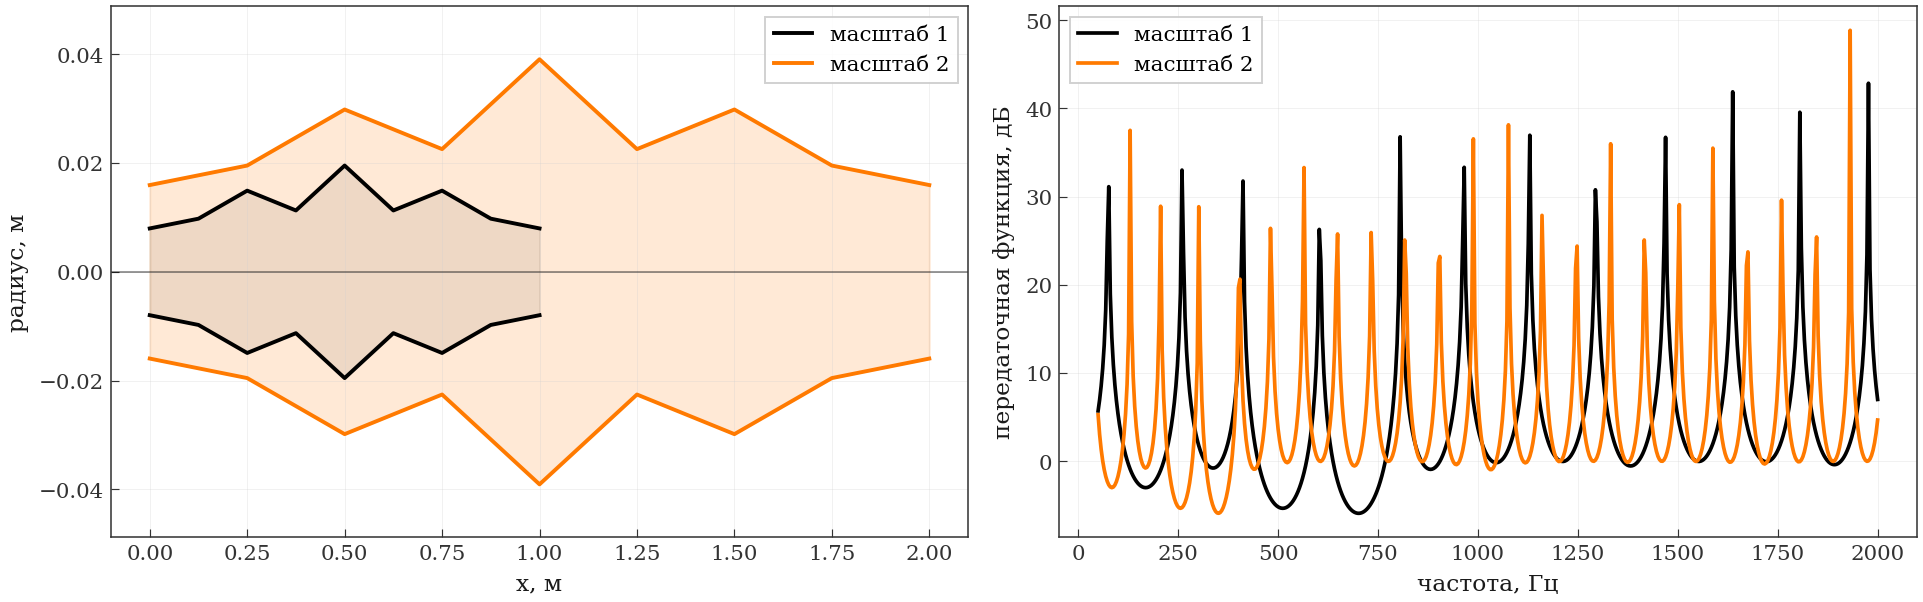

Сохранён график: article/images/совпадение_передаточных_функций_после_обратного_масштабирования.png


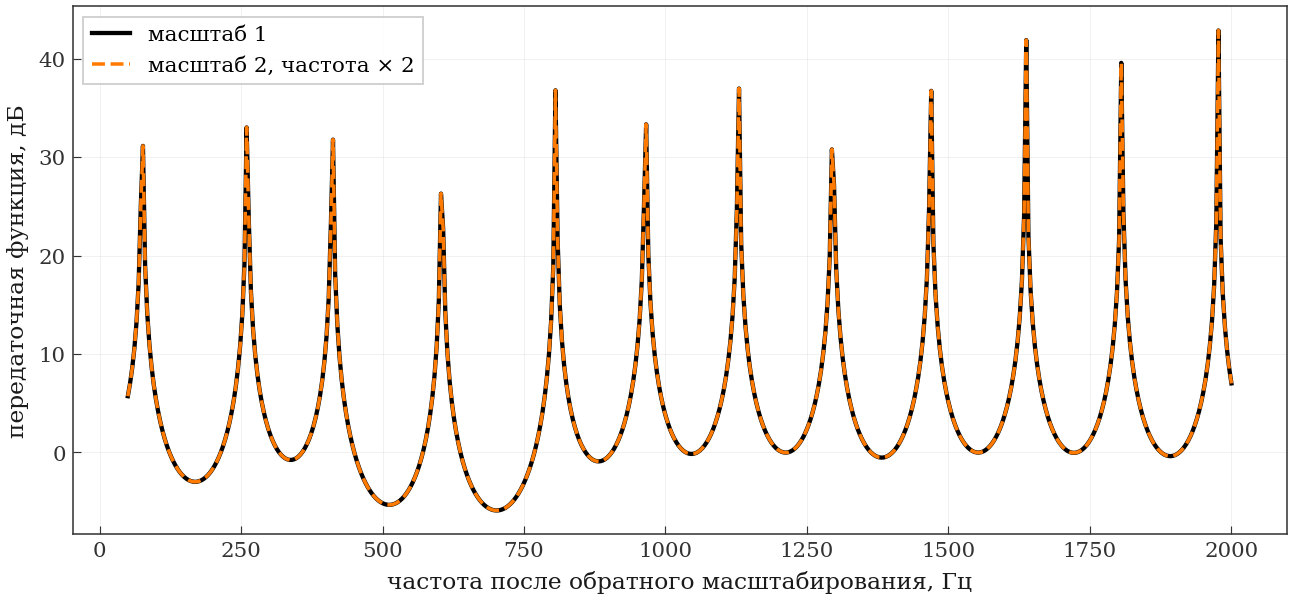

mean abs dB difference after unscaling: 0.0
frequency range: 50.0 ... 2000.0 Hz
length 1: 1.0 m
length 2: 2.0 m
area scale 1: 1.0
area scale 2: 4.0
area min/max 1: 0.0002 0.0012
area min/max 2: 0.0008 0.0048


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import vt_all_solvers_wrapper as vt


# Same dimensionless profile, different full geometric scale.
# Length scale changes x, area scale changes area.
length_scale_1 = 1.0
length_scale_2 = 2.0

area_scale_1 = length_scale_1 ** 2
area_scale_2 = length_scale_2 ** 2

base_length_m = 1.0

x_norm = np.linspace(0.0, 1.0, 9)

base_area_m2 = np.array(
    [
        2.0e-4,
        3.0e-4,
        7.0e-4,
        4.0e-4,
        1.2e-3,
        4.0e-4,
        7.0e-4,
        3.0e-4,
        2.0e-4,
    ],
    dtype=float,
)

geometry_1 = vt.ExplicitGeometry(
    x_m=(length_scale_1 * base_length_m * x_norm).tolist(),
    area_m2=(area_scale_1 * base_area_m2).tolist(),
)

geometry_2 = vt.ExplicitGeometry(
    x_m=(length_scale_2 * base_length_m * x_norm).tolist(),
    area_m2=(area_scale_2 * base_area_m2).tolist(),
)

solver_config = vt.SolverConfig(
    solver="cone",
    sections=100,
    points=512,
    f_min_hz=50.0,
    f_max_hz=2000.0,
    grid="linear",
    beta_loss_np_per_m=0.0,
)

result_1 = vt.solve(geometry_1, config=solver_config)
result_2 = vt.solve(geometry_2, config=solver_config)

freq_1 = np.asarray(result_1.frequencies_hz)
freq_2 = np.asarray(result_2.frequencies_hz)

mag_db_1 = 20.0 * np.log10(np.maximum(np.asarray(result_1.magnitude), 1e-12))
mag_db_2 = 20.0 * np.log10(np.maximum(np.asarray(result_2.magnitude), 1e-12))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

def plot_symmetric_geometry(ax, geometry, *, color, label, linewidth=1.8, alpha=0.14):
    x_m = np.asarray(geometry.x_m, dtype=float)
    area_m2 = np.asarray(geometry.area_m2, dtype=float)
    radius_m = np.sqrt(area_m2 / np.pi)

    ax.plot(x_m, radius_m, color=color, linewidth=linewidth, label=label)
    ax.plot(x_m, -radius_m, color=color, linewidth=linewidth)
    ax.fill_between(x_m, -radius_m, radius_m, color=color, alpha=alpha)

plot_symmetric_geometry(
    axes[0],
    geometry_1,
    color=COLORS["black"],
    label=f"масштаб {length_scale_1:g}",
    linewidth=2.0,
    alpha=0.08,
)
plot_symmetric_geometry(
    axes[0],
    geometry_2,
    color=COLORS["orange"],
    label=f"масштаб {length_scale_2:g}",
    linewidth=2.0,
    alpha=0.16,
)
axes[0].axhline(0.0, color="black", linewidth=0.8, alpha=0.5)
axes[0].set_xlabel("x, м")
axes[0].set_ylabel("радиус, м")
axes[0].set_title("Геометрии после полного масштабирования")
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc="upper right")
max_radius = max(
    np.sqrt(np.asarray(geometry_1.area_m2, dtype=float) / np.pi).max(),
    np.sqrt(np.asarray(geometry_2.area_m2, dtype=float) / np.pi).max(),
)
axes[0].set_ylim(-1.25 * max_radius, 1.25 * max_radius)
axes[0].set_aspect("auto")

axes[1].plot(
    freq_1,
    mag_db_1,
    linewidth=1.9,
    color=COLORS["black"],
    label=f"масштаб {length_scale_1:g}",
)
axes[1].plot(
    freq_2,
    mag_db_2,
    linewidth=1.9,
    color=COLORS["orange"],
    label=f"масштаб {length_scale_2:g}",
)
axes[1].set_xlabel("частота, Гц")
axes[1].set_ylabel("передаточная функция, дБ")
axes[1].set_title("Численные передаточные функции")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

fig.suptitle(
    "Одинаковый профиль канала при полном геометрическом масштабировании",
    fontsize=14,
)
fig.tight_layout()
save_current_figure(
    fig,
    filename_title="Полное геометрическое масштабирование канала",
    hide_titles=True,
)
plt.show()
plt.close()

# Проверка совпадения после обратного масштабирования частот.
# Для полного геометрического масштабирования в s раз резонансы сдвигаются
# как f -> f / s, поэтому для сравнения растягиваем частотную ось обратно.
scale_ratio = length_scale_2 / length_scale_1
unscale_config = vt.SolverConfig(
    solver=solver_config.solver,
    sections=solver_config.sections,
    points=solver_config.points,
    f_min_hz=solver_config.f_min_hz / scale_ratio,
    f_max_hz=solver_config.f_max_hz / scale_ratio,
    grid=solver_config.grid,
    beta_loss_np_per_m=solver_config.beta_loss_np_per_m,
)

result_2_unscaled = vt.solve(geometry_2, config=unscale_config)
freq_2_unscaled = np.asarray(result_2_unscaled.frequencies_hz) * scale_ratio
mag_db_2_unscaled = 20.0 * np.log10(
    np.maximum(np.asarray(result_2_unscaled.magnitude), 1e-12)
)

fig, ax = plt.subplots(figsize=(9.5, 4.8))
ax.plot(
    freq_1,
    mag_db_1,
    linewidth=2.2,
    color=COLORS["black"],
    label=f"масштаб {length_scale_1:g}",
)
ax.plot(
    freq_2_unscaled,
    mag_db_2_unscaled,
    linewidth=1.8,
    color=COLORS["orange"],
    linestyle="--",
    label=f"масштаб {length_scale_2:g}, частота × {scale_ratio:g}",
)
ax.set_xlabel("частота после обратного масштабирования, Гц")
ax.set_ylabel("передаточная функция, дБ")
ax.set_title("Совпадение передаточных функций после обратного масштабирования")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
save_current_figure(
    fig,
    filename_title="Совпадение передаточных функций после обратного масштабирования",
    hide_titles=True,
)
plt.show()
plt.close()

mean_abs_unscaled_db_difference = np.mean(np.abs(mag_db_2_unscaled - mag_db_1))
print("mean abs dB difference after unscaling:", mean_abs_unscaled_db_difference)

print("frequency range:", solver_config.f_min_hz, "...", solver_config.f_max_hz, "Hz")
print("length 1:", max(geometry_1.x_m) - min(geometry_1.x_m), "m")
print("length 2:", max(geometry_2.x_m) - min(geometry_2.x_m), "m")

print("area scale 1:", area_scale_1)
print("area scale 2:", area_scale_2)

print("area min/max 1:", min(geometry_1.area_m2), max(geometry_1.area_m2))
print("area min/max 2:", min(geometry_2.area_m2), max(geometry_2.area_m2))


## Красота

In [ ]:
import matplotlib.pyplot as plt

ds.apply_style(font_size=12, fig_width_cm=18.0, fig_height_cm=10.0, dpi=140, closed_frame=True)
plt.rcParams["axes.prop_cycle"] = plt.cycler(
    color=[
        ds.COLORS["blue"],
        "#FF7A00",
        ds.COLORS["green"],
        ds.COLORS["red"],
        ds.COLORS["purple"],
        ds.COLORS["cyan"],
        ds.COLORS["pink"],
    ]
)

COLORS = {
    "black": ds.COLORS["black"],
    "blue": ds.COLORS["blue"],
    "orange": "#FF7A00",
    "green": ds.COLORS["green"],
    "magenta": ds.COLORS["purple"],
    "grid": "#D9D9D9",
    "original": ds.COLORS["black"],
    "cones": ds.COLORS["green"],
    "cylinders": "#FF7A00",
    "webster": ds.COLORS["green"],
    "arma": ds.COLORS["pink"],
    "axis": "#334155",
}


In [ ]:
def magnitude_to_db(magnitude, eps=1e-12):
    return [20.0 * math.log10(max(abs(v), eps)) for v in magnitude]


ref_result = worst_case.comparison.results[reference_solver]
cmp_result = worst_case.comparison.results[worst_solver]

plt.figure(figsize=(8, 4.8))

plt.plot(
    ref_result.frequencies_hz,
    magnitude_to_db(ref_result.magnitude),
    color=COLORS["black"],
    linewidth=2.4,
    label=f"{reference_solver} (эталон)",
)

plt.plot(
    cmp_result.frequencies_hz,
    magnitude_to_db(cmp_result.magnitude),
    color=COLORS["blue"],
    linewidth=1.9,
    label=worst_solver,
)

plt.xlabel("частота, Гц")
plt.ylabel(r"$|H(f)|$, дБ")
plt.title("Сравнение передаточных функций в худшем случае")
plt.legend()
plt.tight_layout()
save_current_figure()
plt.show()
plt.close()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

vt.plot_geometry_approximation(
    worst_case.geometry,
    section_count=quality_config.sections,
    approx="cylinders",
    color_approx=COLORS["cylinders"],
    mode="symmetric",
    ax=axes[0],
    title="Worst Case: Cylindrical Approximation",
    equal_aspect=False,
    linewidth_original=2.2,
    linewidth_approx=1.8,
)

vt.plot_geometry_approximation(
    worst_case.geometry,
    section_count=quality_config.sections,
    approx="cones",
    color_approx=COLORS["cones"],
    mode="symmetric",
    ax=axes[1],
    title="Worst Case: Cone Approximation",
    equal_aspect=False,
    linewidth_original=2.2,
    linewidth_approx=1.8,
)

plt.tight_layout()
save_current_figure()
plt.show()
plt.close()


In [ ]:
import matplotlib.pyplot as plt

ds.apply_style(font_size=12, fig_width_cm=18.0, fig_height_cm=10.0, dpi=140, closed_frame=True)
plt.rcParams["axes.prop_cycle"] = plt.cycler(
    color=[
        ds.COLORS["blue"],
        "#FF7A00",
        ds.COLORS["green"],
        ds.COLORS["red"],
        ds.COLORS["purple"],
        ds.COLORS["cyan"],
        ds.COLORS["pink"],
    ]
)

COLORS = {
    "black": ds.COLORS["black"],
    "blue": ds.COLORS["blue"],
    "orange": "#FF7A00",
    "green": ds.COLORS["green"],
    "magenta": ds.COLORS["purple"],
    "grid": "#D9D9D9",
    "original": ds.COLORS["black"],
    "cones": ds.COLORS["green"],
    "cylinders": "#FF7A00",
    "webster": ds.COLORS["green"],
    "arma": ds.COLORS["pink"],
    "axis": "#334155",
}


In [ ]:
import math

geom = vt.make_geometry_from_range_library("random_piecewise", range_library, seed=1)
section_count = 24

fig, ax = plt.subplots(figsize=(8.2, 4.8))

x_m, area_m2 = vt.geometry_to_arrays(geom)
r_m = [math.sqrt(a / math.pi) for a in area_m2]

ax.plot(x_m, r_m, color=COLORS["original"], linewidth=2.6, label="исходный профиль")
ax.plot(x_m, [-r for r in r_m], color=COLORS["original"], linewidth=2.6)

sections = vt.approximate_with_cones(geom, section_count)
xs = [sections[0]["left_x_m"]]
upper = [math.sqrt(sections[0]["area_in_m2"] / math.pi)]
for sec in sections:
    xs.append(sec["right_x_m"])
    upper.append(math.sqrt(sec["area_out_m2"] / math.pi))
lower = [-v for v in upper]

ax.plot(xs, upper, color=COLORS["cones"], linewidth=2.0, label=f"конусы ({section_count})")
ax.plot(xs, lower, color=COLORS["cones"], linewidth=2.0)
ax.fill_between(xs, lower, upper, color=COLORS["cones"], alpha=0.12)

ax.axhline(0.0, color="#94A3B8", linewidth=0.9, alpha=0.8)
ax.set_xlabel("x, м")
ax.set_ylabel("радиус, м")
ax.set_title("Геометрия канала и коническая аппроксимация")
ax.legend(loc="upper left")

plt.tight_layout()
save_current_figure()
plt.show()
plt.close()


In [ ]:
plt.figure(figsize=(7.6, 4.8))

plt.plot(
    section_counts,
    [100 * e for e in mean_err_cyl],
    marker="o",
    markersize=5.5,
    linewidth=2.2,
    color=COLORS["cylinders"],
    label="цилиндры",
)

plt.plot(
    section_counts,
    [100 * e for e in mean_err_cone],
    marker="o",
    markersize=5.5,
    linewidth=2.2,
    color=COLORS["cones"],
    label="конусы",
)

plt.xlabel("число секций")
plt.ylabel("средняя относительная ошибка площади, %")
plt.title("Ошибка аппроксимации в зависимости от числа секций")
plt.legend()
plt.tight_layout()
save_current_figure()
plt.show()
plt.close()


In [ ]:
def magnitude_to_db(magnitude, eps=1e-12):
    return [20.0 * math.log10(max(abs(v), eps)) for v in magnitude]

ref_result = worst_case.comparison.results[reference_solver]
cmp_result = worst_case.comparison.results[worst_solver]

plt.figure(figsize=(8.2, 4.8))

plt.plot(
    ref_result.frequencies_hz,
    magnitude_to_db(ref_result.magnitude),
    color=COLORS["original"],
    linewidth=2.6,
    label=f"{reference_solver} эталон",
)

plt.plot(
    cmp_result.frequencies_hz,
    magnitude_to_db(cmp_result.magnitude),
    color=COLORS["cones"],
    linewidth=2.0,
    label=worst_solver,
)

plt.xlabel("частота, Гц")
plt.ylabel(r"$|H(f)|$, дБ")
plt.title("Сравнение передаточных функций в худшем случае")
plt.legend()

plt.tight_layout()
save_current_figure()
plt.show()
plt.close()


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

vt.plot_geometry_approximation(
    worst_case.geometry,
    section_count=quality_config.sections,
    approx="cylinders",
    color_approx=COLORS["cylinders"],
    mode="symmetric",
    ax=axes[0],
    title="Worst Case: Cylindrical Approximation",
    equal_aspect=False,
    linewidth_original=2.4,
    linewidth_approx=1.9,
)

vt.plot_geometry_approximation(
    worst_case.geometry,
    section_count=quality_config.sections,
    approx="cones",
    color_approx=COLORS["cones"],
    mode="symmetric",
    ax=axes[1],
    title="Worst Case: Cone Approximation",
    equal_aspect=False,
    linewidth_original=2.4,
    linewidth_approx=1.9,
)

plt.tight_layout()
save_current_figure()
plt.show()
plt.close()


## Датасет

In [ ]:
import importlib
import matplotlib.pyplot as plt
import vt_all_solvers_wrapper as vt
import dataset

from base_range_library import range_library
from dataset import StreamingGeometryDatasetConfig, make_streaming_dataloader

importlib.reload(vt)
importlib.reload(dataset)

batch_size = 50
n_show = 30

train_config = StreamingGeometryDatasetConfig(
    geometry_kind="random",
    target_mode="db",
    return_geometry=True,
    return_metadata=True,
    seed=1,
)

train_loader = make_streaming_dataloader(
    train_config,
    range_library,
    batch_size=batch_size,
    num_workers=0,
)

geometries = []
solutions_db = []
frequencies_hz = []
metadata = []

for batch in train_loader:
    geom = batch["geometry"]

    x = geom["x_m"]
    area = geom["area_m2"]
    node_count = geom["node_count"]

    target = batch["target"]
    freq = batch["frequencies_hz"]
    meta = batch.get("meta", None)

    for i in range(x.shape[0]):
        n = int(node_count[i])

        geometry = vt.ExplicitGeometry(
            x_m=x[i, :n].cpu().tolist(),
            area_m2=area[i, :n].cpu().tolist(),
        )

        geometries.append(geometry)
        solutions_db.append(target[i].detach().cpu())
        frequencies_hz.append(freq[i].detach().cpu())

        if meta is not None:
            metadata.append(meta[i])
        else:
            metadata.append(None)

        if len(geometries) >= n_show:
            break

    if len(geometries) >= n_show:
        break


# 1) Геометрии каналов
fig, axes = plt.subplots(5, 6, figsize=(18, 12))
axes = axes.ravel()

for idx, geometry in enumerate(geometries):
    kind = ""
    if metadata[idx] is not None and "geometry_kind" in metadata[idx]:
        kind = f" ({metadata[idx]['geometry_kind']})"
    elif metadata[idx] is not None and "geometry_kind_requested" in metadata[idx]:
        kind = f" ({metadata[idx]['geometry_kind_requested']})"

    vt.plot_geometry(
        geometry,
        mode="symmetric",
        ax=axes[idx],
        title=f"channel {idx + 1}{kind}",
        equal_aspect=True,
        linewidth=1.0,
    )

for ax in axes[len(geometries):]:
    ax.axis("off")

fig.suptitle("Первые 30 профилей каналов из обучающей выборки", fontsize=14)
fig.tight_layout()
save_current_figure()
plt.show()
plt.close()


# 2) Численные решения для тех же каналов
fig, axes = plt.subplots(5, 6, figsize=(18, 12))
axes = axes.ravel()

for idx, (freq, solution_db) in enumerate(zip(frequencies_hz, solutions_db)):
    axes[idx].plot(freq, solution_db, linewidth=1.1, color="tab:blue")
    axes[idx].set_title(f"решение {idx + 1}")
    axes[idx].set_xlabel("Гц")
    axes[idx].set_ylabel("дБ")
    axes[idx].grid(True, alpha=0.3)

for ax in axes[len(solutions_db):]:
    ax.axis("off")

fig.suptitle("Численные передаточные функции для тех же 30 каналов", fontsize=14)
fig.tight_layout()
save_current_figure()
plt.show()
plt.close()
